In [ ]:
#-----
#Imports:--

import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import json
import time
import hashlib
import math
import random
import string
from dataclasses import dataclass
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS
from tqdm.auto import tqdm
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ["punkt", "wordnet", "omw-1.4", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

In [ ]:
#------
#Data:--
DATA_CSV = "enron_emails.csv"

TEXT_COL_CANDIDATES = ["message", "text", "Message", "content"]
LABEL_COL_CANDIDATES = ["label", "Label", "target", "class"]

#Config:--
MODEL_NAME = "bert-base-uncased"
POOL_EXCLUDE_CLS = True
MAX_LENGTH = 512
BATCH_SIZE = 64
LR = 5e-5
EPOCHS = 2
WEIGHT_DECAY = 0.01
USE_BEST_VAL_CHECKPOINT = False

N_SPLITS = 5
SEED = 99

#running only for best models:--
TOPK_K_LIST = [10]
HYBRID_K_LIST = [3]
RUN_CLS = True
RUN_TOPK = True
RUN_HYBRID = True
RUN_GMAX = False

MAGIC_WORD_BUDGET_LIST = [15]

ATTACK_AMOUNT = 100
DMAX = 0.06
PGD_ETA = 0.01
PGD_MAX_ITER = 1000
IMPORTANT_FEATURE_TOPN = 100
DEFAULT_MAGIC_WORD_BUDGET = 15

OUT_DIR = "spam_topk_adv_cv_outputs_concat_enron512_dim_analysis"
PLOT_DIR = os.path.join(OUT_DIR, "plots")
FOLD_PLOT_DIR = os.path.join(PLOT_DIR, "per_fold_asr")
COSINE_PLOT_DIR = os.path.join(PLOT_DIR, "cosine_shift")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(FOLD_PLOT_DIR, exist_ok=True)
os.makedirs(COSINE_PLOT_DIR, exist_ok=True)

#Device:--
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.set_device(0)
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("CUDA available:", torch.cuda.is_available())
print("Visible GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))

ALL_REQUESTED_K = sorted(set(TOPK_K_LIST + HYBRID_K_LIST))
print("TOPK_K_LIST:", TOPK_K_LIST)
print("HYBRID_K_LIST:", HYBRID_K_LIST)
print("MAGIC_WORD_BUDGET_LIST:", MAGIC_WORD_BUDGET_LIST)

CUDA_VISIBLE_DEVICES: 1
CUDA available: True
Visible GPU count: 1
Current CUDA device: 0
GPU name: NVIDIA RTX 6000 Ada Generation
TOPK_K_LIST: [10]
HYBRID_K_LIST: [3]
MAGIC_WORD_BUDGET_LIST: [15]


In [3]:
import os, torch
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("visible gpu count =", torch.cuda.device_count())
print("current device =", torch.cuda.current_device() if torch.cuda.is_available() else "cpu")
print("device name =", torch.cuda.get_device_name(torch.cuda.current_device()) if torch.cuda.is_available() else "cpu")

CUDA_VISIBLE_DEVICES = 1
visible gpu count = 1
current device = 0
device name = NVIDIA RTX 6000 Ada Generation


In [ ]:
#------
#Loading data:--

df = pd.read_csv(DATA_CSV)

# Detect columns
text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
label_col = next((c for c in LABEL_COL_CANDIDATES if c in df.columns), None)

if text_col is None or label_col is None:
    raise ValueError(
        f"Could not auto-detect text/label columns.\n"
        f"Found columns: {list(df.columns)}\n"
        f"Set TEXT_COL_CANDIDATES / LABEL_COL_CANDIDATES or rename columns."
    )

print("Using text column :", text_col)
print("Using label column:", label_col)

df = df[[text_col, label_col]].dropna().copy()
df[text_col] = df[text_col].astype(str)

#Normalize labels -> {0,1}
if df[label_col].dtype == object:
    label_map = {}
    uniq_lower = sorted(df[label_col].astype(str).str.strip().str.lower().unique().tolist())
    print("Original label values:", uniq_lower)

    # common spam/ham conventions
    if set(uniq_lower).issubset({"ham", "spam"}):
        label_map = {"ham": 0, "spam": 1}
        df[label_col] = df[label_col].astype(str).str.strip().str.lower().map(label_map)
    else:
        # try generic binary mapping
        uniq = sorted(df[label_col].astype(str).unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"Expected binary labels, got {uniq}")
        label_map = {uniq[0]: 0, uniq[1]: 1}
        df[label_col] = df[label_col].astype(str).map(label_map)
        print("[Info] Applied generic mapping:", label_map)
else:
    df[label_col] = df[label_col].astype(int)
    uniq = sorted(df[label_col].unique().tolist())
    if set(uniq) == {1, 2}:  # common variant
        df[label_col] = df[label_col].map({1: 0, 2: 1})
    elif not set(uniq).issubset({0, 1}):
        raise ValueError(f"Expected binary numeric labels in {{0,1}} (or {{1,2}}), got {uniq}")

df = df.rename(columns={text_col: "message", label_col: "label"}).reset_index(drop=True)
print(df.head())
print("\nLabel counts:\n", df["label"].value_counts())

Using text column : message
Using label column: label
                                             message  label
0  Subject: enron / hpl actuals for november 13 ,...      0
1  Subject: enron actuals for march 30 - april 1 ...      0
2  Subject: hpl noms for february 15 , 2000\n( se...      0
3  Subject: txu noms . for 10 / 14 - 16 / 00\natt...      0
4  Subject: re : nom / actual vols for 24 th\n- -...      0

Label counts:
 label
1    17171
0    16545
Name: count, dtype: int64


In [ ]:
#------
#Preprocessing:--


def remove_hyperlink(text):
    return re.sub(r"http\S+", " ", text)

def to_lower(text):
    return text.lower()

def remove_number(text):
    return re.sub(r"\d+", " ", text)

def remove_punctuation(text):
    return text.translate(str.maketrans(dict.fromkeys(string.punctuation)))

def remove_whitespace(text):
    return text.strip()

def replace_newline(text):
    return text.replace("\n", " ")

def clean_up_pipeline(sentence):
    if not isinstance(sentence, str):
        sentence = str(sentence)
    for fn in [remove_hyperlink, replace_newline, to_lower, remove_number, remove_punctuation, remove_whitespace]:
        sentence = fn(sentence)
    return sentence

def remove_stop_words(words):
    return [w for w in words if w not in ENGLISH_STOP_WORDS]

def word_lemmatizer(words):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in words]

def clean_token_pipeline(words):
    for fn in [remove_stop_words, word_lemmatizer]:
        words = fn(words)
    return words

def preprocess_for_tfidf(x_train, x_val, x_test):
    x_train = [str(x) for x in x_train]
    x_val   = [str(x) for x in x_val]
    x_test  = [str(x) for x in x_test]

    x_train_clean = [clean_up_pipeline(x) for x in x_train]
    x_val_clean   = [clean_up_pipeline(x) for x in x_val]
    x_test_clean  = [clean_up_pipeline(x) for x in x_test]

    x_train_tok = [word_tokenize(x) for x in x_train_clean]
    x_val_tok   = [word_tokenize(x) for x in x_val_clean]
    x_test_tok  = [word_tokenize(x) for x in x_test_clean]

    x_train_tok = [clean_token_pipeline(x) for x in x_train_tok]
    x_val_tok   = [clean_token_pipeline(x) for x in x_val_tok]
    x_test_tok  = [clean_token_pipeline(x) for x in x_test_tok]

    x_train_proc = [" ".join(x) for x in x_train_tok]
    x_val_proc   = [" ".join(x) for x in x_val_tok]
    x_test_proc  = [" ".join(x) for x in x_test_tok]

    return x_train_proc, x_val_proc, x_test_proc

In [ ]:
#------
#Magic-word pipeline:--

@dataclass
class _DatasetWrap:
    X: object
    Y: np.ndarray

def _prep_X(X):
    if sp.issparse(X):
        return X
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return X

def _prep_y(y):
    return np.asarray(y).ravel()

def feature_extraction_tfidf(x_train_proc, x_val_proc, x_test_proc):
    vectorizer = TfidfVectorizer()
    vectorizer.fit(list(x_train_proc)) 
    x_train_features = vectorizer.transform(x_train_proc)
    x_val_features   = vectorizer.transform(x_val_proc)
    x_test_features  = vectorizer.transform(x_test_proc)
    feature_names = vectorizer.get_feature_names_out()
    return x_train_features, x_val_features, x_test_features, feature_names, vectorizer

def train_svm_with_cv(x_train_features, x_val_features, y_train, y_val, seed=SEED):
    x_tr = _prep_X(x_train_features)
    x_va = _prep_X(x_val_features)
    y_tr = _prep_y(y_train)
    y_va = _prep_y(y_val)

    tr_set = _DatasetWrap(x_tr, y_tr)
    v_set  = _DatasetWrap(x_va, y_va)

    clf_base = LinearSVC(dual="auto", max_iter=5000, random_state=seed)
    param_grid = {"C": [1]}  # keep simple / same spirit as notebook
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    search = GridSearchCV(
        clf_base, param_grid, scoring="accuracy", cv=inner_cv, n_jobs=-1
    )
    search.fit(tr_set.X, tr_set.Y)
    clf_lin = search.best_estimator_
    clf_lin.fit(tr_set.X, tr_set.Y)

    y_pred_val = clf_lin.predict(v_set.X)
    cm = confusion_matrix(v_set.Y, y_pred_val, labels=[0, 1])

    return tr_set, v_set, clf_lin, cm

def pgd_attack_linear_svc(
    clf_lin, v_set, y_val, feature_names,
    nb_attack=ATTACK_AMOUNT, dmax=DMAX,
    lb=0.0, ub=1.0, eta=PGD_ETA, max_iter=PGD_MAX_ITER
):
    """
    PGD-like evasion attack against LinearSVC in TF-IDF space.
    Attacks class 1 (spam) toward class 0 (ham).
    Returns a dataframe of successful perturbation deltas.
    """
    def to_dense_row(x):
        if sp.issparse(x):
            return x.toarray().ravel()
        return np.asarray(x).ravel()

    def clip_bounds(x, lb_vec, ub_vec):
        return np.minimum(np.maximum(x, lb_vec), ub_vec)

    def project_l2(x, x0, eps):
        d = x - x0
        n = np.linalg.norm(d)
        if n > eps:
            d = d * (eps / (n + 1e-12))
        return x0 + d

    Xv = v_set.X
    yv = np.asarray(y_val).ravel()

    n_features = Xv.shape[1]
    lb_vec = np.full(n_features, lb) if np.ndim(lb) == 0 else np.asarray(lb).ravel()
    ub_vec = np.full(n_features, ub) if np.ndim(ub) == 0 else np.asarray(ub).ravel()

    idx_candidates = np.where(yv == 1)[0]  # spam samples only
    if idx_candidates.size == 0:
        return pd.DataFrame(columns=feature_names), 0, 0.0

    picks = np.random.choice(idx_candidates, size=min(nb_attack, idx_candidates.size), replace=False)

    w = clf_lin.coef_.reshape(-1)
    ori_examples_x = []
    ad_examples_x = []
    ad_examples_y = []
    success_count = 0

    for idx in picks:
        x0 = to_dense_row(Xv[idx])
        x_adv = x0.copy()

        for _ in range(max_iter):
            grad = w
            x_adv = x_adv - eta * grad
            x_adv = clip_bounds(x_adv, lb_vec, ub_vec)
            x_adv = project_l2(x_adv, x0, dmax)

            y_pred = int(clf_lin.predict(x_adv.reshape(1, -1))[0])
            if y_pred == 0:  # flipped to ham
                break

        y_adv_pred = int(clf_lin.predict(x_adv.reshape(1, -1))[0])

        ori_examples_x.append(x0.copy())
        ad_examples_x.append(x_adv.copy())
        ad_examples_y.append(y_adv_pred)

        if y_adv_pred == 0:
            success_count += 1

    if len(ad_examples_x) == 0:
        return pd.DataFrame(columns=feature_names), 0, 0.0

    ori_df = pd.DataFrame(np.array(ori_examples_x), columns=feature_names)
    ad_df  = pd.DataFrame(np.array(ad_examples_x), columns=feature_names)
    ad_df["ad_label"] = np.array(ad_examples_y)

    # Keep successful attacks only
    success_mask = ad_df["ad_label"] == 0
    ad_success = ad_df.loc[success_mask].drop(columns=["ad_label"])
    ori_success = ori_df.loc[success_mask]

    if len(ad_success) == 0:
        result = pd.DataFrame(columns=feature_names)
    else:
        result = (ad_success - ori_success)

    success_rate = success_count / len(picks) if len(picks) else 0.0
    return result, success_count, success_rate

def extract_magic_words(
    x_train_proc, x_val_proc, y_train, y_val,
    x_test_proc, y_test,
    result_df, cnt_success,
    important_feature_topn=IMPORTANT_FEATURE_TOPN,
    magic_word_budget=None,
):
    if magic_word_budget is None:
        magic_word_budget = DEFAULT_MAGIC_WORD_BUDGET
    """
    Fold-wise 'magic words' extraction:
    - attack-derived important features
    - keep ham-only words (not in spam vocab)
    - intersect with important features
    """
    if cnt_success <= 0 or result_df is None or len(result_df) == 0:
        return "", [], [], []

    result_array = np.array(result_df)
    weighted_result = result_df.multiply(result_array)

    average_importance = weighted_result.sum() / max(cnt_success, 1)
    average_importance_df = pd.DataFrame(average_importance, columns=["importance"])
    sorted_features = average_importance_df.sort_values(by="importance", ascending=False)
    important_features = sorted_features.index[:important_feature_topn].tolist()

    train_data = pd.DataFrame({"message": x_train_proc, "label": y_train})
    val_data   = pd.DataFrame({"message": x_val_proc, "label": y_val})
    combined = pd.concat([train_data, val_data], ignore_index=True)

    spam_messages = combined[combined["label"] == 1]
    ham_messages  = combined[combined["label"] == 0]

    tfidf_spam = TfidfVectorizer()
    tfidf_ham  = TfidfVectorizer()

    spam_feature_names = set()
    ham_feature_names = set()

    if len(spam_messages) > 0:
        tfidf_spam.fit_transform(spam_messages["message"])
        spam_feature_names = set(tfidf_spam.get_feature_names_out())
    if len(ham_messages) > 0:
        tfidf_ham.fit_transform(ham_messages["message"])
        ham_feature_names = set(tfidf_ham.get_feature_names_out())

    unique_ham_words = list(ham_feature_names - spam_feature_names)
    ham_words_in_important = list(set(unique_ham_words).intersection(set(important_features)))

    importance_rank = {w: i for i, w in enumerate(important_features)}
    ham_words_in_important = sorted(ham_words_in_important, key=lambda w: importance_rank.get(w, 10**9))

    # keep only top-N magic words by importance rank
    if magic_word_budget is not None:
        try:
            budget = int(magic_word_budget)
        except Exception:
            budget = None
        if budget is not None and budget > 0:
            ham_words_in_important = ham_words_in_important[:budget]

    magic_words_str = " ".join(ham_words_in_important)
    spam_test_messages = pd.DataFrame({"message": x_test_proc, "label": y_test}).query("label==1")["message"].tolist()

    return magic_words_str, important_features, unique_ham_words, spam_test_messages

def build_magic_words_for_fold(
    X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test,
    magic_word_budget=DEFAULT_MAGIC_WORD_BUDGET,
    verbose=True
):
    x_train_proc, x_val_proc, x_test_proc = preprocess_for_tfidf(X_train_raw, X_val_raw, X_test_raw)

    x_train_features, x_val_features, x_test_features, feature_names, vectorizer = feature_extraction_tfidf(
        x_train_proc, x_val_proc, x_test_proc
    )

    #SVM training:--
    tr_set, v_set, clf_lin, cm_val = train_svm_with_cv(x_train_features, x_val_features, y_train, y_val)

    # bounds from train feature range
    x_train_dense = x_train_features.toarray()
    lb = float(np.min(x_train_dense))
    ub = float(np.max(x_train_dense))

    result_df, cnt_success, success_rate = pgd_attack_linear_svc(
        clf_lin, v_set, y_val, feature_names,
        nb_attack=ATTACK_AMOUNT, dmax=DMAX, lb=lb, ub=ub
    )

    magic_words_str, important_features, unique_ham_words, spam_test_messages = extract_magic_words(
    x_train_proc, x_val_proc, y_train, y_val, x_test_proc, y_test,
    result_df, cnt_success,
    magic_word_budget=magic_word_budget
    )

    if verbose:
        print("SVM val confusion matrix:\n", cm_val)
        print(f"PGD success_count={cnt_success}, success_rate={success_rate:.4f}")
        print(f"Magic words count={len(magic_words_str.split()) if magic_words_str else 0}")
        print("Magic words:", magic_words_str if magic_words_str else "<none>")

    details = {
        "svm_val_cm": cm_val.tolist(),
        "pgd_success_count": int(cnt_success),
        "pgd_success_rate": float(success_rate),
        "important_features_topN": important_features,
        "unique_ham_words_count": int(len(unique_ham_words)),
        "spam_test_count_proc": int(len(spam_test_messages)),
    }
    return magic_words_str, details

In [ ]:
#------
#computing fold cache:--

def make_adv_test_set(test_df, magic_words_str):
    """
    Append fold-specific magic words ONLY to spam messages.
    Ham messages stay unchanged.
    """
    out = test_df.copy().reset_index(drop=True)
    magic_suffix = (" " + magic_words_str.strip()) if str(magic_words_str).strip() else ""
    spam_mask = out["label"] == 1

    out["message_clean"] = out["message"].astype(str)
    out["message_adv"] = out["message_clean"].astype(str)
    out.loc[spam_mask, "message_adv"] = out.loc[spam_mask, "message_clean"].astype(str) + magic_suffix

    out["is_attacked"] = spam_mask.astype(int)
    out["magic_words_used"] = magic_words_str
    return out


def _norm_text_hash(s: str) -> str:
    s = ("" if s is None else str(s)).strip().lower()
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()

def _split_overlap_stats(df_train, df_val, df_test):
    tr = set(df_train["message"].astype(str).map(_norm_text_hash))
    va = set(df_val["message"].astype(str).map(_norm_text_hash))
    te = set(df_test["message"].astype(str).map(_norm_text_hash))
    return {
        "train_val_overlap": int(len(tr & va)),
        "train_test_overlap": int(len(tr & te)),
        "val_test_overlap": int(len(va & te)),
    }


def build_fold_cache(df_all, n_splits=N_SPLITS, seed=SEED, magic_word_budget=DEFAULT_MAGIC_WORD_BUDGET, verbose=True):
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_cache = []

    splits = list(skf.split(df_all["message"].values, df_all["label"].values))
    for fold_id, (trainval_idx, test_idx) in enumerate(splits, start=1):
        fold_trainval = df_all.iloc[trainval_idx].reset_index(drop=True)
        fold_test     = df_all.iloc[test_idx].reset_index(drop=True)

        tr_idx_local, val_idx_local = train_test_split(
            np.arange(len(fold_trainval)),
            test_size=0.25,  # 0.25 * 0.80 = 0.20 total
            random_state=seed + fold_id,
            stratify=fold_trainval["label"].values
        )

        df_train = fold_trainval.iloc[tr_idx_local].reset_index(drop=True)
        df_val   = fold_trainval.iloc[val_idx_local].reset_index(drop=True)
        df_test  = fold_test.reset_index(drop=True)

        if verbose:
            print(f"\n================ Fold {fold_id}/{n_splits} cache build ================")
            print("train/val/test:", len(df_train), len(df_val), len(df_test))
            print("train label counts:", df_train["label"].value_counts().to_dict())
            print("val   label counts:", df_val["label"].value_counts().to_dict())
            print("test  label counts:", df_test["label"].value_counts().to_dict())

        t0 = time.perf_counter()
        magic_words_str, magic_details = build_magic_words_for_fold(
        df_train["message"].tolist(),
        df_val["message"].tolist(),
        df_test["message"].tolist(),
        df_train["label"].values,
        df_val["label"].values,
        df_test["label"].values,
        magic_word_budget=magic_word_budget,
        verbose=verbose
        )
        magic_elapsed = time.perf_counter() - t0

        adv_test_df = make_adv_test_set(df_test, magic_words_str)
        overlap_stats = _split_overlap_stats(df_train, df_val, df_test)

        fold_cache.append({
            "fold_id": fold_id,
            "df_train": df_train,
            "df_val": df_val,
            "df_test_clean": df_test,
            "df_test_adv": adv_test_df,
            "magic_words_str": magic_words_str,
            "magic_word_budget": int(magic_word_budget) if magic_word_budget is not None else np.nan,
            "magic_word_count": int(len(magic_words_str.split()) if magic_words_str else 0),
            "magic_details": magic_details,
            "magic_build_seconds": float(magic_elapsed),
            "overlap_hash_stats": overlap_stats,
        })

    return fold_cache

In [ ]:
if "fold_magic_rows" not in globals() or len(fold_magic_rows) == 0:
    print("No fold_magic_rows found yet. Run the main experiment cell first.")
else:
    fold_magic_df = pd.DataFrame(fold_magic_rows)
    fold_magic_df = fold_magic_df.sort_values(["magic_word_budget", "fold_id"]).reset_index(drop=True)

    print("\n=== Magic words used in all folds / budgets ===")
    display(fold_magic_df)

    fold_magic_df.to_csv(os.path.join(OUT_DIR, "magic_words_by_fold.csv"), index=False)

    counter = Counter()
    for s in fold_magic_df["magic_words_str"].fillna("").astype(str):
        for w in s.split():
            counter[w] += 1

    magic_freq_df = pd.DataFrame(
        [{"word": w, "count_across_folds": c} for w, c in counter.items()]
    ).sort_values(["count_across_folds", "word"], ascending=[False, True]).reset_index(drop=True)

    magic_freq_df.to_csv(os.path.join(OUT_DIR, "magic_words_token_frequency.csv"), index=False)

    print("\nTop magic words by frequency across all budgets/folds:")
    display(magic_freq_df.head(30))

In [ ]:
#------
#Tokenizing and model defining:--

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextClsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = [str(x) for x in texts]
        self.labels = [int(y) for y in labels]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {"text": self.texts[idx], "label": self.labels[idx]}

def collate_text_cls(batch):
    return {
        "texts": [b["text"] for b in batch],
        "labels": torch.tensor([b["label"] for b in batch], dtype=torch.long),
    }


class CLSPoolingBERT(nn.Module):
    def __init__(self, model_name="bert-base-uncased", num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = int(getattr(self.bert.config, "hidden_size", 768))
        self.classifier = nn.Linear(hidden, num_labels)

    def encode_pooled(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state
        cls_vec = h[:, 0, :].float()
        return cls_vec

    def forward(self, input_ids, attention_mask, labels=None, return_pooled=False):
        pooled = self.encode_pooled(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        out = {"loss": loss, "logits": logits}
        if return_pooled:
            out["pooled"] = pooled
        return out


class TopKDimPoolingBERT(nn.Module):
    def __init__(self, model_name="bert-base-uncased", k=10, num_labels=2, exclude_cls=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.k = int(k)
        self.exclude_cls = bool(exclude_cls)
        hidden = int(getattr(self.bert.config, "hidden_size", 768))
        self.classifier = nn.Linear(hidden, num_labels)

    def encode_pooled(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state

        mask = attention_mask.to(dtype=torch.bool)
        if self.exclude_cls and mask.size(1) > 0:
            mask = mask.clone()
            mask[:, 0] = False

        x = h.float()
        very_neg = torch.tensor(-1e9, device=x.device, dtype=x.dtype)
        x = x.masked_fill(~mask.unsqueeze(-1), very_neg)

        k_eff = max(1, min(int(self.k), int(x.size(1))))
        vals, _ = torch.topk(x, k=k_eff, dim=1)

        valid = vals > -5e8
        denom = valid.sum(dim=1).clamp(min=1)
        pooled = (vals * valid).sum(dim=1) / denom
        return pooled

    def forward(self, input_ids, attention_mask, labels=None, return_pooled=False):
        pooled = self.encode_pooled(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        out = {"loss": loss, "logits": logits}
        if return_pooled:
            out["pooled"] = pooled
        return out


class HybridCLSTopKConcatBERT(nn.Module):
    def __init__(self, model_name="bert-base-uncased", k=3, num_labels=2, exclude_cls=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.k = int(k)
        self.exclude_cls = bool(exclude_cls)
        hidden = int(getattr(self.bert.config, "hidden_size", 768))
        self.classifier = nn.Linear(hidden * 2, num_labels)

    def encode_pooled(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h = outputs.last_hidden_state

        cls_vec = h[:, 0, :].float()

        mask = attention_mask.to(dtype=torch.bool)
        if self.exclude_cls and mask.size(1) > 0:
            mask = mask.clone()
            mask[:, 0] = False

        x = h.float()
        very_neg = torch.tensor(-1e9, device=x.device, dtype=x.dtype)
        x = x.masked_fill(~mask.unsqueeze(-1), very_neg)

        k_eff = max(1, min(int(self.k), int(x.size(1))))
        vals, _ = torch.topk(x, k=k_eff, dim=1)

        valid = vals > -5e8
        denom = valid.sum(dim=1).clamp(min=1)
        topk_vec = (vals * valid).sum(dim=1) / denom

        hybrid_vec = torch.cat([cls_vec, topk_vec], dim=1)
        return hybrid_vec

    def forward(self, input_ids, attention_mask, labels=None, return_pooled=False):
        pooled = self.encode_pooled(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        out = {"loss": loss, "logits": logits}
        if return_pooled:
            out["pooled"] = pooled
        return out


def build_model(model_type: str, k_value: int):
    mt = model_type.lower()
    if mt == "cls":
        return CLSPoolingBERT(model_name=MODEL_NAME, num_labels=2).to(device)
    elif mt == "topk":
        return TopKDimPoolingBERT(
            model_name=MODEL_NAME,
            k=k_value,
            num_labels=2,
            exclude_cls=POOL_EXCLUDE_CLS
        ).to(device)
    elif mt == "hybrid":
        return HybridCLSTopKConcatBERT(
            model_name=MODEL_NAME,
            k=k_value,
            num_labels=2,
            exclude_cls=POOL_EXCLUDE_CLS
        ).to(device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

In [ ]:
#------
#Train:--

@torch.no_grad()
def predict_model(model, loader, tokenizer, device, max_length=MAX_LENGTH):
    model.eval()
    all_true, all_pred, all_prob1 = [], [], []

    for batch in loader:
        enc = tokenizer(
            batch["texts"],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = out["logits"]
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        all_prob1.extend(probs[:, 1].cpu().numpy().tolist())

    return np.array(all_true), np.array(all_pred), np.array(all_prob1)

@torch.no_grad()
def get_pooled_vectors(model, texts, tokenizer, device, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    model.eval()
    all_pooled = []

    texts = [str(x) for x in texts]
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask, return_pooled=True)
        pooled = out["pooled"].detach().cpu().float()
        all_pooled.append(pooled)

    if len(all_pooled) == 0:
        return np.zeros((0, 768), dtype=np.float32)

    return torch.cat(all_pooled, dim=0).numpy()

def _rowwise_cosine_numpy(a, b, eps=1e-12):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    a_norm = np.linalg.norm(a, axis=1)
    b_norm = np.linalg.norm(b, axis=1)
    denom = np.clip(a_norm * b_norm, eps, None)

    cos = np.sum(a * b, axis=1) / denom
    cos = np.clip(cos, -1.0, 1.0)
    return cos

@torch.no_grad()
def compute_cosine_shift_rows(fc, model, model_type, k_value, magic_budget):
    clean_df = fc["df_test_clean"].reset_index(drop=True).copy()
    adv_df = fc["df_test_adv"].reset_index(drop=True).copy()

    if len(clean_df) != len(adv_df):
        raise ValueError(
            f"Clean/adv length mismatch in fold {fc['fold_id']}: "
            f"{len(clean_df)} vs {len(adv_df)}"
        )

    clean_text_col = "message" if "message" in clean_df.columns else "text"
    adv_text_col = "message_adv" if "message_adv" in adv_df.columns else ("message" if "message" in adv_df.columns else "text")

    clean_texts = clean_df[clean_text_col].astype(str).tolist()
    adv_texts = adv_df[adv_text_col].astype(str).tolist()
    labels = clean_df["label"].astype(int).to_numpy()

    pooled_clean = get_pooled_vectors(model, clean_texts, tokenizer, device, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)
    pooled_adv = get_pooled_vectors(model, adv_texts, tokenizer, device, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)

    if pooled_clean.shape != pooled_adv.shape:
        raise ValueError(
            f"Pooled shape mismatch in fold {fc['fold_id']} for model={model_type}: "
            f"{pooled_clean.shape} vs {pooled_adv.shape}"
        )

    sample_id_col = None
    for cand in ["sample_id", "id", "row_id"]:
        if cand in clean_df.columns:
            sample_id_col = cand
            break

    if sample_id_col is not None:
        sample_ids = clean_df[sample_id_col].astype(str).tolist()
    else:
        sample_ids = [f"fold{int(fc['fold_id'])}_pos{i}" for i in range(len(clean_df))]

    spam_idx = np.where(labels == 1)[0]
    if len(spam_idx) == 0:
        return []

    cos_vals = _rowwise_cosine_numpy(pooled_clean[spam_idx], pooled_adv[spam_idx])
    shift_vals = 1.0 - cos_vals

    model_type_l = str(model_type).lower()
    k_out = int(k_value) if model_type_l in {"topk", "hybrid"} else np.nan

    rows = []
    for local_j, idx in enumerate(spam_idx):
        rows.append({
            "magic_word_budget": int(magic_budget),
            "fold_id": int(fc["fold_id"]),
            "sample_pos": int(idx),
            "sample_id": sample_ids[idx],
            "label": int(labels[idx]),
            "model_type": model_type_l,
            "k": k_out,
            "cosine_similarity": float(cos_vals[local_j]),
            "shift_magnitude": float(shift_vals[local_j]),
            "clean_text_length_chars": int(len(clean_texts[idx])),
            "adv_text_length_chars": int(len(adv_texts[idx])),
            "pooled_dim": int(pooled_clean.shape[1]),
        })
    return rows

def train_one_model(
    model,
    train_loader,
    val_loader,
    tokenizer,
    device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_length=MAX_LENGTH,
    verbose=True
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_macro_f1 = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        n_steps = 0

        pbar = tqdm(train_loader, desc=f"Train epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            enc = tokenizer(
                batch["texts"],
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            input_ids = enc["input_ids"].to(device)
            attention_mask = enc["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out["loss"]
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            n_steps += 1
            pbar.set_postfix(loss=f"{total_loss/max(n_steps,1):.4f}")

        y_val_true, y_val_pred, _ = predict_model(model, val_loader, tokenizer, device, max_length=max_length)
        val_rep = classification_report(y_val_true, y_val_pred, output_dict=True, zero_division=0)
        val_acc = float(val_rep["accuracy"])
        val_macro_f1 = float(val_rep["macro avg"]["f1-score"])

        hist_row = {
            "epoch": epoch,
            "train_loss": float(total_loss / max(n_steps, 1)),
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
        }
        history.append(hist_row)

        if verbose:
            print(
                f"Epoch {epoch}/{epochs} | train_loss={hist_row['train_loss']:.4f} | "
                f"val_acc={val_acc:.4f} | val_macro_f1={val_macro_f1:.4f}"
            )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if USE_BEST_VAL_CHECKPOINT and (best_state is not None):
        model.load_state_dict(best_state)

    return model, history

def compute_metrics_bundle(y_true, y_pred):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    spam_mask = y_true == 1
    asr = float((y_pred[spam_mask] == 0).mean()) if spam_mask.sum() > 0 else float("nan")

    return {
        "report": rep,
        "cm": cm,
        "asr": asr,
        "accuracy": float(rep["accuracy"]),
        "macro_f1": float(rep["macro avg"]["f1-score"]),
        "weighted_f1": float(rep["weighted avg"]["f1-score"]),
        "macro_precision": float(rep["macro avg"]["precision"]),
        "macro_recall": float(rep["macro avg"]["recall"]),
    }

def flatten_report(report_dict, prefix):
    rows = []
    for key, val in report_dict.items():
        row = dict(prefix)
        row["report_key"] = key
        if isinstance(val, dict):
            for m, mv in val.items():
                row[m] = float(mv)
        else:
            row["value"] = float(val)
        rows.append(row)
    return rows

In [ ]:
#------
#Main:--

import copy as _copy

summary_rows = []
report_rows = []
fold_level_rows = []
history_rows = []
asr_plot_rows = []
alias_rows = []
k_total_time_rows = []
fold_magic_rows = []
cosine_shift_rows = []

MODEL_RUN_CACHE = {}

def evaluate_one_fold_model(fc, model_type, k_value, magic_budget, verbose=True):
    """
    Train one model on one fold and evaluate on clean and adversarial test.
    Also computes cosine-shift rows for malicious test samples.
    """
    fold_id = int(fc["fold_id"])
    model_type_l = str(model_type).lower()

    cache_key = (
        fold_id,
        model_type_l,
        None if model_type_l == "cls" else int(k_value),
        int(magic_budget),
    )
    if cache_key in MODEL_RUN_CACHE:
        return _copy.deepcopy(MODEL_RUN_CACHE[cache_key])

    train_ds = TextClsDataset(fc["df_train"]["message"].tolist(), fc["df_train"]["label"].tolist())
    val_ds   = TextClsDataset(fc["df_val"]["message"].tolist(),   fc["df_val"]["label"].tolist())
    test_clean_ds = TextClsDataset(fc["df_test_clean"]["message"].tolist(), fc["df_test_clean"]["label"].tolist())
    test_adv_ds   = TextClsDataset(fc["df_test_adv"]["message_adv"].tolist(), fc["df_test_adv"]["label"].tolist())

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_text_cls)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)
    test_clean_loader = DataLoader(test_clean_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)
    test_adv_loader   = DataLoader(test_adv_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)

    model = build_model(model_type=model_type_l, k_value=(0 if k_value is None else int(k_value)))

    t0 = time.perf_counter()
    model, history = train_one_model(
        model,
        train_loader,
        val_loader,
        tokenizer,
        device,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        max_length=MAX_LENGTH,
        verbose=verbose
    )
    train_elapsed = time.perf_counter() - t0

    y_true_clean, y_pred_clean, y_prob_clean = predict_model(
        model, test_clean_loader, tokenizer, device, max_length=MAX_LENGTH
    )
    y_true_adv, y_pred_adv, y_prob_adv = predict_model(
        model, test_adv_loader, tokenizer, device, max_length=MAX_LENGTH
    )

    clean_metrics = compute_metrics_bundle(y_true_clean, y_pred_clean)
    adv_metrics   = compute_metrics_bundle(y_true_adv, y_pred_adv)

    shift_rows = compute_cosine_shift_rows(
        fc=fc,
        model=model,
        model_type=model_type_l,
        k_value=(0 if k_value is None else int(k_value)),
        magic_budget=magic_budget
    )

    out_dict = {
        "fold_id": fold_id,
        "model_type": model_type_l,
        "k": (np.nan if model_type_l == "cls" else int(k_value)),
        "history": history,
        "train_elapsed_seconds": float(train_elapsed),

        "y_true_clean": y_true_clean,
        "y_pred_clean": y_pred_clean,
        "y_prob_clean": y_prob_clean,
        "clean_metrics": clean_metrics,

        "y_true_adv": y_true_adv,
        "y_pred_adv": y_pred_adv,
        "y_prob_adv": y_prob_adv,
        "adv_metrics": adv_metrics,

        "cosine_shift_rows": shift_rows,
    }

    MODEL_RUN_CACHE[cache_key] = _copy.deepcopy(out_dict)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return out_dict

for magic_budget in MAGIC_WORD_BUDGET_LIST:
    print("\n" + "#" * 110)
    print(f"RUNNING MAGIC_WORD_BUDGET = {magic_budget}")
    print("#" * 110)

    fold_cache = build_fold_cache(
        df,
        n_splits=N_SPLITS,
        seed=SEED,
        magic_word_budget=magic_budget,
        verbose=True
    )

    print(f"\nBuilt fold cache for {len(fold_cache)} folds for magic budget = {magic_budget}")

    for fc in fold_cache:
        fold_magic_rows.append({
            "magic_word_budget": int(magic_budget),
            "fold_id": int(fc["fold_id"]),
            "magic_words_str": fc["magic_words_str"],
            "magic_word_count": int(fc["magic_word_count"]),
            "magic_build_seconds": float(fc["magic_build_seconds"]),
            "pgd_success_count": int(fc["magic_details"]["pgd_success_count"]),
            "pgd_success_rate": float(fc["magic_details"]["pgd_success_rate"]),
            "svm_val_cm": json.dumps(fc["magic_details"]["svm_val_cm"]),
        })

    MODEL_RUN_CACHE = {}

    experiment_list = [
        ("cls", None),
        ("topk", 10),
        ("hybrid", 3),
    ]

    for model_type, k in experiment_list:
        print("\n" + "=" * 100)
        print(f"RUNNING model={model_type.upper()} | k={k} | magic_budget={magic_budget}")
        print("=" * 100)

        exp_t0 = time.perf_counter()
        agg = {
            model_type: {
                "clean_true": [],
                "clean_pred": [],
                "adv_true": [],
                "adv_pred": [],
                "elapsed": 0.0
            }
        }

        for fc in tqdm(fold_cache, desc=f"Folds for {model_type}, K={k}, magic={magic_budget}", leave=False):
            fold_id = int(fc["fold_id"])

            seed_k = 0 if k is None else int(k)
            set_seed(SEED + 10000 * int(magic_budget) + 1000 * fold_id + 10 * seed_k + len(model_type))

            print(f"\n--- Fold {fold_id} | model={model_type.upper()} | K={k} | magic_budget={magic_budget} ---")

            out = evaluate_one_fold_model(
                fc=fc,
                model_type=model_type,
                k_value=k,
                magic_budget=magic_budget,
                verbose=True
            )

            cosine_shift_rows.extend(out["cosine_shift_rows"])

            for h in out["history"]:
                history_rows.append({
                    "magic_word_budget": int(magic_budget),
                    "k": (np.nan if k is None else int(k)),
                    "fold_id": int(fold_id),
                    "model_type": model_type,
                    **h
                })

            fold_level_rows.append({
                "magic_word_budget": int(magic_budget),
                "k": (np.nan if k is None else int(k)),
                "fold_id": int(fold_id),
                "model_type": model_type,
                "is_alias": False,
                "alias_of": "",
                "train_elapsed_seconds": float(out["train_elapsed_seconds"]),
                "magic_word_count": int(fc["magic_word_count"]),
                "magic_words_str": fc["magic_words_str"],

                "clean_accuracy": out["clean_metrics"]["accuracy"],
                "clean_macro_f1": out["clean_metrics"]["macro_f1"],
                "clean_weighted_f1": out["clean_metrics"]["weighted_f1"],
                "clean_asr_spam_to_ham": out["clean_metrics"]["asr"],

                "adv_accuracy": out["adv_metrics"]["accuracy"],
                "adv_macro_f1": out["adv_metrics"]["macro_f1"],
                "adv_weighted_f1": out["adv_metrics"]["weighted_f1"],
                "adv_asr_spam_to_ham": out["adv_metrics"]["asr"],
            })

            report_rows.extend(flatten_report(
                out["clean_metrics"]["report"],
                {
                    "magic_word_budget": int(magic_budget),
                    "k": (np.nan if k is None else int(k)),
                    "fold_id": int(fold_id),
                    "model_type": model_type,
                    "eval_type": "clean",
                    "is_aggregate": False
                }
            ))
            report_rows.extend(flatten_report(
                out["adv_metrics"]["report"],
                {
                    "magic_word_budget": int(magic_budget),
                    "k": (np.nan if k is None else int(k)),
                    "fold_id": int(fold_id),
                    "model_type": model_type,
                    "eval_type": "adversarial",
                    "is_aggregate": False
                }
            ))

            agg[model_type]["clean_true"].extend(out["y_true_clean"].tolist())
            agg[model_type]["clean_pred"].extend(out["y_pred_clean"].tolist())
            agg[model_type]["adv_true"].extend(out["y_true_adv"].tolist())
            agg[model_type]["adv_pred"].extend(out["y_pred_adv"].tolist())
            agg[model_type]["elapsed"] += float(out["train_elapsed_seconds"])

            asr_plot_rows.append({
                "magic_word_budget": int(magic_budget),
                "k": (np.nan if k is None else int(k)),
                "fold_id": int(fold_id),
                "model_type": model_type,
                "adv_asr_spam_to_ham": float(out["adv_metrics"]["asr"]),
                "is_alias": False,
            })

        clean_true = np.array(agg[model_type]["clean_true"])
        clean_pred = np.array(agg[model_type]["clean_pred"])
        adv_true   = np.array(agg[model_type]["adv_true"])
        adv_pred   = np.array(agg[model_type]["adv_pred"])

        clean_metrics = compute_metrics_bundle(clean_true, clean_pred)
        adv_metrics   = compute_metrics_bundle(adv_true, adv_pred)

        print("\n" + "-" * 90)
        print(f"[AGGREGATED 5-FOLD] magic_budget={magic_budget} | K={k} | MODEL={model_type.upper()}")
        print("\nCLEAN TEST Classification Report:")
        print(classification_report(clean_true, clean_pred, digits=4, zero_division=0))
        print("ADVERSARIAL TEST Classification Report:")
        print(classification_report(adv_true, adv_pred, digits=4, zero_division=0))
        print(f"Adversarial ASR (spam->ham flip rate): {adv_metrics['asr']:.4f}")
        print(f"Training time accumulated across folds: {agg[model_type]['elapsed']/60:.2f} min")
        print("-" * 90)

        summary_rows.append({
            "magic_word_budget": int(magic_budget),
            "k": (np.nan if k is None else int(k)),
            "model_type": model_type,
            "is_alias": False,
            "alias_of": "",
            "train_elapsed_seconds_sum_folds": float(agg[model_type]["elapsed"]),
            "train_elapsed_minutes_sum_folds": float(agg[model_type]["elapsed"] / 60.0),

            "clean_accuracy": clean_metrics["accuracy"],
            "clean_macro_precision": clean_metrics["macro_precision"],
            "clean_macro_recall": clean_metrics["macro_recall"],
            "clean_macro_f1": clean_metrics["macro_f1"],
            "clean_weighted_f1": clean_metrics["weighted_f1"],
            "clean_asr_spam_to_ham": clean_metrics["asr"],

            "adv_accuracy": adv_metrics["accuracy"],
            "adv_macro_precision": adv_metrics["macro_precision"],
            "adv_macro_recall": adv_metrics["macro_recall"],
            "adv_macro_f1": adv_metrics["macro_f1"],
            "adv_weighted_f1": adv_metrics["weighted_f1"],
            "adv_asr_spam_to_ham": adv_metrics["asr"],

            "adv_cm_00": int(adv_metrics["cm"][0][0]),
            "adv_cm_01": int(adv_metrics["cm"][0][1]),
            "adv_cm_10": int(adv_metrics["cm"][1][0]),
            "adv_cm_11": int(adv_metrics["cm"][1][1]),
        })

        report_rows.extend(flatten_report(
            clean_metrics["report"],
            {
                "magic_word_budget": int(magic_budget),
                "k": (np.nan if k is None else int(k)),
                "fold_id": -1,
                "model_type": model_type,
                "eval_type": "clean",
                "is_aggregate": True,
                "is_alias": False
            }
        ))
        report_rows.extend(flatten_report(
            adv_metrics["report"],
            {
                "magic_word_budget": int(magic_budget),
                "k": (np.nan if k is None else int(k)),
                "fold_id": -1,
                "model_type": model_type,
                "eval_type": "adversarial",
                "is_aggregate": True,
                "is_alias": False
            }
        ))

        exp_elapsed = time.perf_counter() - exp_t0
        k_total_time_rows.append({
            "magic_word_budget": int(magic_budget),
            "k": (np.nan if k is None else int(k)),
            "model_type": model_type,
            "total_elapsed_seconds_for_all_folds": float(exp_elapsed),
            "total_elapsed_minutes_for_all_folds": float(exp_elapsed / 60.0),
        })

        print(f"\n[Done] magic_budget={magic_budget} | model={model_type} | k={k} | total={exp_elapsed/60:.2f} min")


##############################################################################################################
RUNNING MAGIC_WORD_BUDGET = 15
##############################################################################################################

================ Fold 1/5 cache build ================
train/val/test: 20229 6743 6744
train label counts: {1: 10302, 0: 9927}
val   label counts: {1: 3434, 0: 3309}
test  label counts: {1: 3435, 0: 3309}
SVM val confusion matrix:
 [[3266   43]
 [  18 3416]]
PGD success_count=82, success_rate=0.8200
Magic words count=10
Magic words: listbot kaminski enrononline ena clickathome calger caiso pjm erisk beenladen

================ Fold 2/5 cache build ================
train/val/test: 20229 6744 6743
train label counts: {1: 10302, 0: 9927}
val   label counts: {1: 3435, 0: 3309}
test  label counts: {1: 3434, 0: 3309}
SVM val confusion matrix:
 [[3269   40]
 [  14 3421]]
PGD success_count=83, success_rate=0.8300
Magic words count=7
Magic word

Folds for cls, K=None, magic=15:   0%|          | 0/5 [00:00<?, ?it/s]


--- Fold 1 | model=CLS | K=None | magic_budget=15 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train epoch 1/2:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 1/2 | train_loss=0.0582 | val_acc=0.9942 | val_macro_f1=0.9942


Train epoch 2/2:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 2/2 | train_loss=0.0071 | val_acc=0.9926 | val_macro_f1=0.9926

------------------------------------------------------------------------------------------
[AGGREGATED 5-FOLD] magic_budget=15 | K=3 | MODEL=HYBRID

CLEAN TEST Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9949    0.9938     16545
           1     0.9950    0.9930    0.9940     17171

    accuracy                         0.9939     33716
   macro avg     0.9939    0.9939    0.9939     33716
weighted avg     0.9939    0.9939    0.9939     33716

ADVERSARIAL TEST Classification Report:
              precision    recall  f1-score   support

           0     0.6264    0.9949    0.7687     16545
           1     0.9886    0.4282    0.5975     17171

    accuracy                         0.7063     33716
   macro avg     0.8075    0.7115    0.6831     33716
weighted avg     0.8108    0.7063    0.6815     33716

Adversarial ASR (spam->ham flip rate): 0.5718
Trainin

In [ ]:
#------
#Saving output:--
summary_df = pd.DataFrame(summary_rows).sort_values(["magic_word_budget", "k", "model_type"]).reset_index(drop=True)
report_df = pd.DataFrame(report_rows).sort_values(["magic_word_budget", "k", "fold_id", "model_type", "eval_type"]).reset_index(drop=True)
fold_level_df = pd.DataFrame(fold_level_rows).sort_values(["magic_word_budget", "k", "fold_id", "model_type"]).reset_index(drop=True)
history_df = pd.DataFrame(history_rows).sort_values(["magic_word_budget", "k", "fold_id", "model_type", "epoch"]).reset_index(drop=True)
asr_plot_df = pd.DataFrame(asr_plot_rows).sort_values(["magic_word_budget", "fold_id", "k", "model_type"]).reset_index(drop=True)
alias_df = pd.DataFrame(alias_rows)
k_time_df = pd.DataFrame(k_total_time_rows).sort_values(["magic_word_budget", "k", "model_type"]).reset_index(drop=True)
cosine_shift_df = pd.DataFrame(cosine_shift_rows).sort_values(
    ["magic_word_budget", "fold_id", "model_type", "sample_pos"]
).reset_index(drop=True)

summary_csv = os.path.join(OUT_DIR, "k_model_summary.csv")
report_csv = os.path.join(OUT_DIR, "classification_reports_flat.csv")
fold_level_csv = os.path.join(OUT_DIR, "fold_level_metrics.csv")
history_csv = os.path.join(OUT_DIR, "training_history.csv")
asr_plot_csv = os.path.join(OUT_DIR, "asr_plot_data.csv")
alias_csv = os.path.join(OUT_DIR, "alias_metadata.csv")
k_time_csv = os.path.join(OUT_DIR, "k_total_times.csv")
cosine_shift_csv = os.path.join(OUT_DIR, "cosine_shift_per_sample.csv")

summary_df.to_csv(summary_csv, index=False)
report_df.to_csv(report_csv, index=False)
fold_level_df.to_csv(fold_level_csv, index=False)
history_df.to_csv(history_csv, index=False)
asr_plot_df.to_csv(asr_plot_csv, index=False)
alias_df.to_csv(alias_csv, index=False)
k_time_df.to_csv(k_time_csv, index=False)
cosine_shift_df.to_csv(cosine_shift_csv, index=False)

print("Saved files:")
for p in [
    summary_csv,
    report_csv,
    fold_level_csv,
    history_csv,
    asr_plot_csv,
    alias_csv,
    k_time_csv,
    cosine_shift_csv,
]:
    print(" -", p)

display(summary_df.head(20))
display(cosine_shift_df.head(20))

Saved files:
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/k_model_summary.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/classification_reports_flat.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/fold_level_metrics.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/training_history.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/asr_plot_data.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/alias_metadata.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/k_total_times.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/cosine_shift_per_sample.csv


,magic_word_budget,k,model_type,is_alias,alias_of,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
0,15,3.0,hybrid,False,,3693.115482,61.551925,0.993890,0.993871,0.993908,...,0.706252,0.807463,0.711513,0.683129,0.681539,0.571836,16460,85,9819,7352
1,15,10.0,topk,False,,3685.678502,61.427975,0.993030,0.992989,0.993091,...,0.620536,0.775423,0.627387,0.564990,0.562104,0.741599,16485,60,12734,4437
2,15,NaN,cls,False,,3658.224631,60.970411,0.993178,0.993160,0.993195,...,0.740450,0.821942,0.745073,0.725255,0.724055,0.503931,16447,98,8653,8518


,magic_word_budget,fold_id,sample_pos,sample_id,label,model_type,k,cosine_similarity,shift_magnitude,clean_text_length_chars,adv_text_length_chars,pooled_dim
0,15,1,760,fold1_pos760,1,cls,NaN,-0.152199,1.152199e+00,122,200,768
1,15,1,761,fold1_pos761,1,cls,NaN,0.405986,5.940139e-01,206,284,768
2,15,1,762,fold1_pos762,1,cls,NaN,0.711463,2.885371e-01,356,434,768
3,15,1,763,fold1_pos763,1,cls,NaN,0.344834,6.551661e-01,369,447,768
4,15,1,764,fold1_pos764,1,cls,NaN,0.551103,4.488972e-01,1352,1430,768
5,15,1,765,fold1_pos765,1,cls,NaN,1.000000,0.000000e+00,4031,4109,768
6,15,1,766,fold1_pos766,1,cls,NaN,1.000000,0.000000e+00,3506,3584,768
7,15,1,767,fold1_pos767,1,cls,NaN,-0.360603,1.360603e+00,158,236,768
8,15,1,768,fold1_pos768,1,cls,NaN,0.817377,1.826231e-01,866,944,768
9,15,1,769,fold1_pos769,1,cls,NaN,-0.294274,1.294274e+00,159,237,768


In [ ]:
#------
#Quick comparison tables:--

TABLE_MAGIC_BUDGET = 15   # choose the budget you want to inspect

table_df = summary_df[summary_df["magic_word_budget"] == TABLE_MAGIC_BUDGET].copy()
table_df = table_df.sort_values(["k", "model_type"]).reset_index(drop=True)

adv_comp = table_df[[
    "magic_word_budget", "k", "model_type", "is_alias", "train_elapsed_minutes_sum_folds",
    "adv_accuracy", "adv_macro_f1", "adv_weighted_f1", "adv_asr_spam_to_ham"
]].sort_values(["k", "model_type"])

print(f"Aggregate adversarial comparison for magic_word_budget={TABLE_MAGIC_BUDGET}:")
display(adv_comp)

pivot_asr = table_df.pivot(index="k", columns="model_type", values="adv_asr_spam_to_ham").sort_index()
pivot_f1 = table_df.pivot(index="k", columns="model_type", values="adv_macro_f1").sort_index()

print("Pivot ASR (lower better):")
display(pivot_asr)

print("Pivot Adversarial Macro-F1 (higher better):")
display(pivot_f1)

Aggregate adversarial comparison for magic_word_budget=15:


,magic_word_budget,k,model_type,is_alias,train_elapsed_minutes_sum_folds,adv_accuracy,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham
0,15,3.0,hybrid,False,61.551925,0.706252,0.683129,0.681539,0.571836
1,15,10.0,topk,False,61.427975,0.620536,0.564990,0.562104,0.741599
2,15,NaN,cls,False,60.970411,0.740450,0.725255,0.724055,0.503931


Pivot ASR (lower better):


model_type,cls,hybrid,topk
k,,,
3.0,NaN,0.571836,NaN
10.0,NaN,NaN,0.741599
NaN,0.503931,NaN,NaN


Pivot Adversarial Macro-F1 (higher better):


model_type,cls,hybrid,topk
k,,,
3.0,NaN,0.683129,NaN
10.0,NaN,NaN,0.56499
NaN,0.725255,NaN,NaN


In [ ]:
#------
#Best K for TopKAvg method:--

BESTK_MAGIC_BUDGET = 15

topk_only = summary_df[
    (summary_df["model_type"] == "topk") &
    (summary_df["magic_word_budget"] == BESTK_MAGIC_BUDGET)
].sort_values("k")

if len(topk_only) > 0:
    best_f1_row = topk_only.loc[topk_only["adv_macro_f1"].idxmax()]
    best_asr_row = topk_only.loc[topk_only["adv_asr_spam_to_ham"].idxmin()]

    print(f"Best TopK by adversarial Macro-F1 for magic_word_budget={BESTK_MAGIC_BUDGET}:")
    display(best_f1_row.to_frame().T)

    print(f"Best TopK by adversarial ASR for magic_word_budget={BESTK_MAGIC_BUDGET}:")
    display(best_asr_row.to_frame().T)

Best TopK by adversarial Macro-F1 for magic_word_budget=15:


,magic_word_budget,k,model_type,is_alias,alias_of,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
1,15,10.0,topk,False,,3685.678502,61.427975,0.99303,0.992989,0.993091,...,0.620536,0.775423,0.627387,0.56499,0.562104,0.741599,16485,60,12734,4437


Best TopK by adversarial ASR for magic_word_budget=15:


,magic_word_budget,k,model_type,is_alias,alias_of,train_elapsed_seconds_sum_folds,train_elapsed_minutes_sum_folds,clean_accuracy,clean_macro_precision,clean_macro_recall,...,adv_accuracy,adv_macro_precision,adv_macro_recall,adv_macro_f1,adv_weighted_f1,adv_asr_spam_to_ham,adv_cm_00,adv_cm_01,adv_cm_10,adv_cm_11
1,15,10.0,topk,False,,3685.678502,61.427975,0.99303,0.992989,0.993091,...,0.620536,0.775423,0.627387,0.56499,0.562104,0.741599,16485,60,12734,4437


Rows selected for cosine plots:
CLS: 17171
Top-K (K=10): 17171
Hybrid (K=3): 17171



Saved cosine-shift analysis files:
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/cosine_shift_summary.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/cosine_shift_pairwise.csv
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/cosine_shift_pairwise_summary.csv


,magic_word_budget,model_type,k,n_samples,mean_shift,median_shift,std_shift,min_shift,max_shift,mean_cosine_similarity,median_cosine_similarity
0,15,cls,NaN,17171,0.572141,0.614735,0.385851,0.0,1.385318,0.427859,0.385265
1,15,hybrid,3.0,17171,0.348881,0.368359,0.281726,0.0,1.384399,0.651119,0.631641
2,15,topk,10.0,17171,0.536451,0.550221,0.344797,0.0,1.575162,0.463549,0.449779


,pair_name,model_a,k_a,model_b,k_b,n_samples,mean_shift_delta,median_shift_delta,std_shift_delta,frac_positive,mean_shift_a,mean_shift_b,mean_cosine_a,mean_cosine_b
0,cls_minus_hybrid,cls,NaN,hybrid,3,17171,0.22326,0.108808,0.374436,0.652321,0.572141,0.348881,0.427859,0.651119
1,cls_minus_topk,cls,NaN,topk,10,17171,0.03569,0.000000,0.315670,0.491061,0.572141,0.536451,0.427859,0.463549
2,hybrid_minus_topk,hybrid,3.0,topk,10,17171,-0.18757,-0.168310,0.213116,0.164813,0.348881,0.536451,0.651119,0.463549


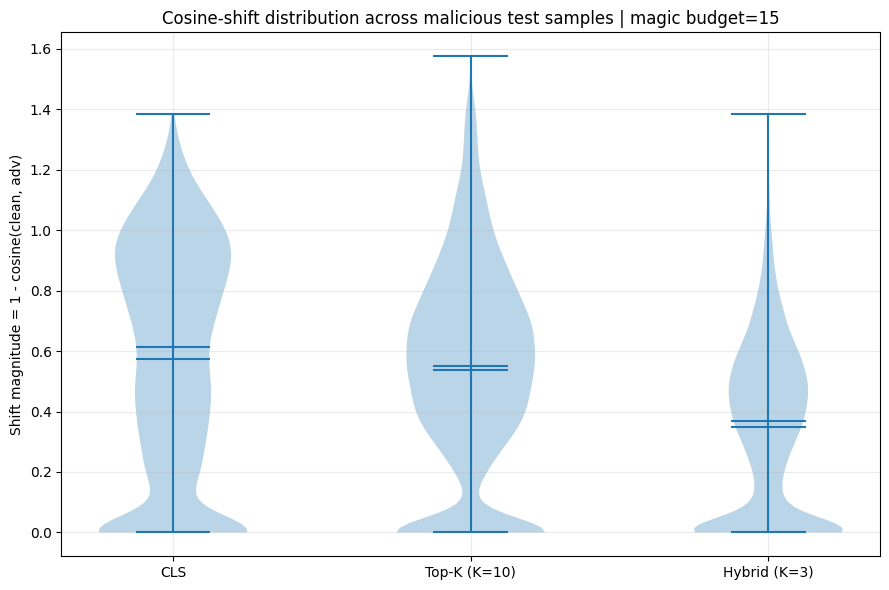

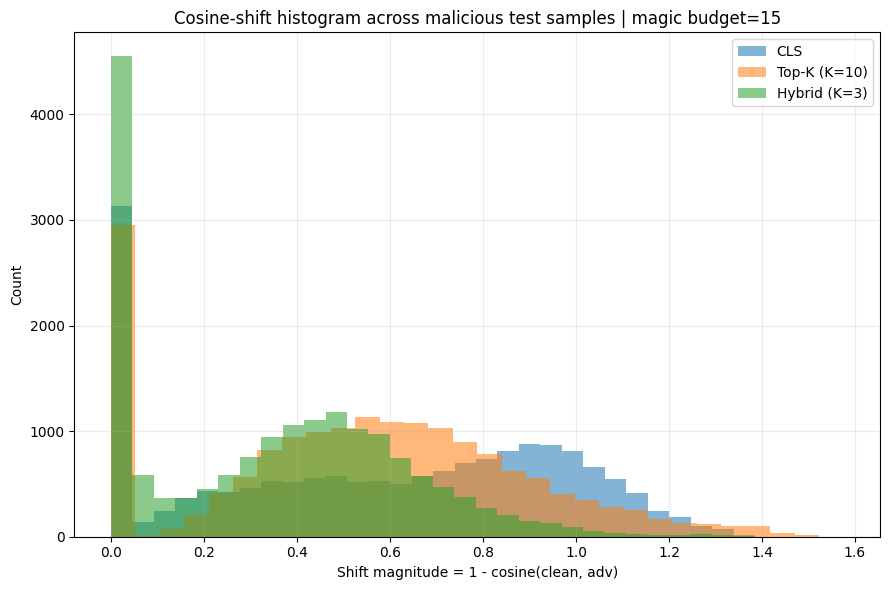

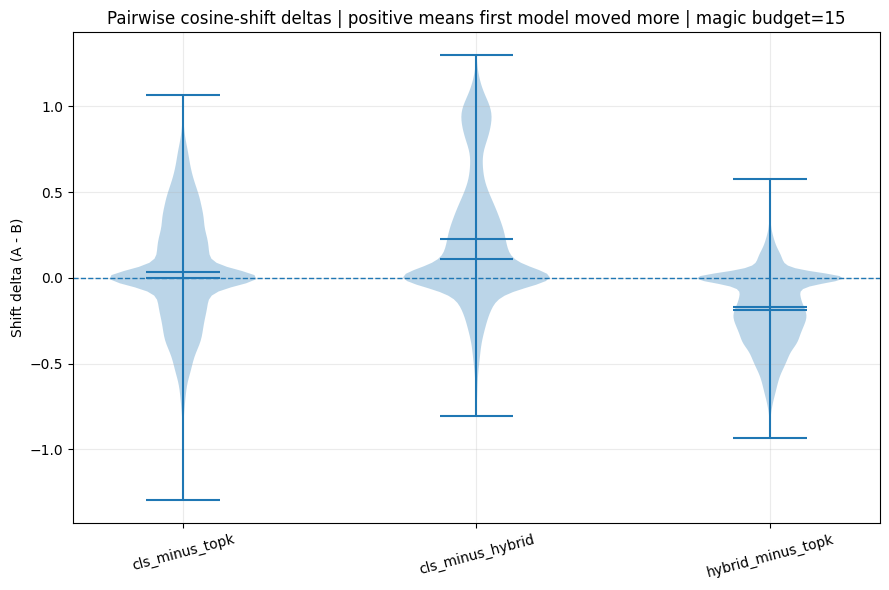

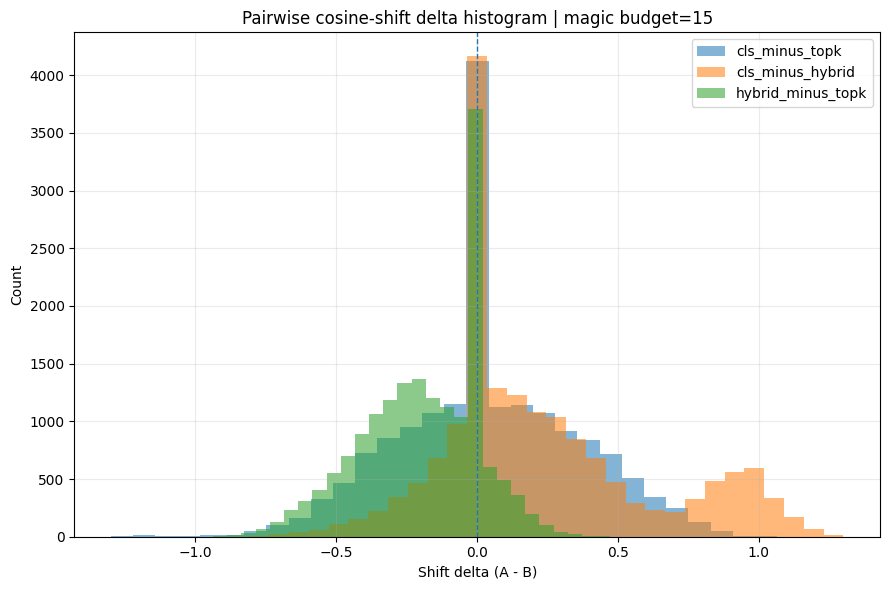


Saved cosine-shift plots:
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/plots/cosine_shift/cosine_shift_violin_magic_15.png
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/plots/cosine_shift/cosine_shift_hist_magic_15.png
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/plots/cosine_shift/cosine_shift_pairwise_violin_magic_15.png
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/plots/cosine_shift/cosine_shift_pairwise_hist_magic_15.png


In [ ]:
#------
# 15) Cosine similarity shift analysis:--

COSINE_MAGIC_BUDGET = 15

def _prepare_model_slice(df, model_type, k_value=None):
    out = df[df["model_type"] == model_type].copy()
    if k_value is None:
        return out
    return out[out["k"] == k_value].copy()

cos_plot_df = cosine_shift_df[cosine_shift_df["magic_word_budget"] == COSINE_MAGIC_BUDGET].copy()

cls_df = _prepare_model_slice(cos_plot_df, "cls", None)
topk_df = _prepare_model_slice(cos_plot_df, "topk", 10)
hybrid_df = _prepare_model_slice(cos_plot_df, "hybrid", 3)

print("Rows selected for cosine plots:")
print("CLS:", len(cls_df))
print("Top-K (K=10):", len(topk_df))
print("Hybrid (K=3):", len(hybrid_df))

cosine_shift_summary_df = (
    cos_plot_df
    .groupby(["magic_word_budget", "model_type", "k"], dropna=False)
    .agg(
        n_samples=("shift_magnitude", "size"),
        mean_shift=("shift_magnitude", "mean"),
        median_shift=("shift_magnitude", "median"),
        std_shift=("shift_magnitude", "std"),
        min_shift=("shift_magnitude", "min"),
        max_shift=("shift_magnitude", "max"),
        mean_cosine_similarity=("cosine_similarity", "mean"),
        median_cosine_similarity=("cosine_similarity", "median"),
    )
    .reset_index()
    .sort_values(["model_type", "k"], na_position="first")
    .reset_index(drop=True)
)

pair_specs = [
    ("cls", None, "topk", 10, "cls_minus_topk"),
    ("cls", None, "hybrid", 3, "cls_minus_hybrid"),
    ("hybrid", 3, "topk", 10, "hybrid_minus_topk"),
]

pairwise_rows = []
merge_keys = ["magic_word_budget", "fold_id", "sample_pos", "sample_id", "label"]

for model_a, k_a, model_b, k_b, pair_name in pair_specs:
    a_df = _prepare_model_slice(cos_plot_df, model_a, k_a)[merge_keys + ["shift_magnitude", "cosine_similarity"]].copy()
    b_df = _prepare_model_slice(cos_plot_df, model_b, k_b)[merge_keys + ["shift_magnitude", "cosine_similarity"]].copy()

    a_df = a_df.rename(columns={
        "shift_magnitude": "shift_a",
        "cosine_similarity": "cosine_a",
    })
    b_df = b_df.rename(columns={
        "shift_magnitude": "shift_b",
        "cosine_similarity": "cosine_b",
    })

    merged = a_df.merge(b_df, on=merge_keys, how="inner", validate="one_to_one")
    if len(merged) == 0:
        print(f"[Warning] No rows found for pair {pair_name}")
        continue

    merged["pair_name"] = pair_name
    merged["model_a"] = model_a
    merged["model_b"] = model_b
    merged["k_a"] = k_a if k_a is not None else np.nan
    merged["k_b"] = k_b if k_b is not None else np.nan
    merged["shift_delta_a_minus_b"] = merged["shift_a"] - merged["shift_b"]
    merged["cosine_delta_a_minus_b"] = merged["cosine_a"] - merged["cosine_b"]

    pairwise_rows.append(merged)

if len(pairwise_rows) > 0:
    cosine_shift_pairwise_df = pd.concat(pairwise_rows, axis=0, ignore_index=True)
else:
    cosine_shift_pairwise_df = pd.DataFrame()

if len(cosine_shift_pairwise_df) > 0:
    cosine_shift_pairwise_summary_df = (
        cosine_shift_pairwise_df
        .groupby(["pair_name", "model_a", "k_a", "model_b", "k_b"], dropna=False)
        .agg(
            n_samples=("shift_delta_a_minus_b", "size"),
            mean_shift_delta=("shift_delta_a_minus_b", "mean"),
            median_shift_delta=("shift_delta_a_minus_b", "median"),
            std_shift_delta=("shift_delta_a_minus_b", "std"),
            frac_positive=("shift_delta_a_minus_b", lambda x: float(np.mean(np.asarray(x) > 0))),
            mean_shift_a=("shift_a", "mean"),
            mean_shift_b=("shift_b", "mean"),
            mean_cosine_a=("cosine_a", "mean"),
            mean_cosine_b=("cosine_b", "mean"),
        )
        .reset_index()
        .sort_values("pair_name")
        .reset_index(drop=True)
    )
else:
    cosine_shift_pairwise_summary_df = pd.DataFrame()

cosine_shift_summary_csv = os.path.join(OUT_DIR, "cosine_shift_summary.csv")
cosine_shift_pairwise_csv = os.path.join(OUT_DIR, "cosine_shift_pairwise.csv")
cosine_shift_pairwise_summary_csv = os.path.join(OUT_DIR, "cosine_shift_pairwise_summary.csv")

cosine_shift_summary_df.to_csv(cosine_shift_summary_csv, index=False)
cosine_shift_pairwise_df.to_csv(cosine_shift_pairwise_csv, index=False)
cosine_shift_pairwise_summary_df.to_csv(cosine_shift_pairwise_summary_csv, index=False)

print("\nSaved cosine-shift analysis files:")
print(" -", cosine_shift_summary_csv)
print(" -", cosine_shift_pairwise_csv)
print(" -", cosine_shift_pairwise_summary_csv)

display(cosine_shift_summary_df)
display(cosine_shift_pairwise_summary_df)

#Violin plot:--
raw_groups = [
    cls_df["shift_magnitude"].dropna().to_numpy(),
    topk_df["shift_magnitude"].dropna().to_numpy(),
    hybrid_df["shift_magnitude"].dropna().to_numpy(),
]
raw_labels = ["CLS", "Top-K (K=10)", "Hybrid (K=3)"]

plt.figure(figsize=(9, 6))
plt.violinplot(raw_groups, showmeans=True, showmedians=True)
plt.xticks([1, 2, 3], raw_labels, rotation=0)
plt.ylabel("Shift magnitude = 1 - cosine(clean, adv)")
plt.title(f"Cosine-shift distribution across malicious test samples | magic budget={COSINE_MAGIC_BUDGET}")
plt.grid(alpha=0.25)
plt.tight_layout()
raw_violin_path = os.path.join(COSINE_PLOT_DIR, f"cosine_shift_violin_magic_{COSINE_MAGIC_BUDGET}.png")
plt.savefig(raw_violin_path, dpi=200, bbox_inches="tight")
plt.show()

#histogram plot:--
plt.figure(figsize=(9, 6))
plt.hist(cls_df["shift_magnitude"].dropna().to_numpy(), bins=30, alpha=0.55, label="CLS")
plt.hist(topk_df["shift_magnitude"].dropna().to_numpy(), bins=30, alpha=0.55, label="Top-K (K=10)")
plt.hist(hybrid_df["shift_magnitude"].dropna().to_numpy(), bins=30, alpha=0.55, label="Hybrid (K=3)")
plt.xlabel("Shift magnitude = 1 - cosine(clean, adv)")
plt.ylabel("Count")
plt.title(f"Cosine-shift histogram across malicious test samples | magic budget={COSINE_MAGIC_BUDGET}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
raw_hist_path = os.path.join(COSINE_PLOT_DIR, f"cosine_shift_hist_magic_{COSINE_MAGIC_BUDGET}.png")
plt.savefig(raw_hist_path, dpi=200, bbox_inches="tight")
plt.show()

#violin of pairwise shift deltas:--
if len(cosine_shift_pairwise_df) > 0:
    pair_order = ["cls_minus_topk", "cls_minus_hybrid", "hybrid_minus_topk"]
    violin_data = [
        cosine_shift_pairwise_df.loc[
            cosine_shift_pairwise_df["pair_name"] == pn, "shift_delta_a_minus_b"
        ].dropna().to_numpy()
        for pn in pair_order
    ]

    plt.figure(figsize=(9, 6))
    plt.violinplot(violin_data, showmeans=True, showmedians=True)
    plt.xticks([1, 2, 3], pair_order, rotation=15)
    plt.ylabel("Shift delta (A - B)")
    plt.title(f"Pairwise cosine-shift deltas | positive means first model moved more | magic budget={COSINE_MAGIC_BUDGET}")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    pair_violin_path = os.path.join(COSINE_PLOT_DIR, f"cosine_shift_pairwise_violin_magic_{COSINE_MAGIC_BUDGET}.png")
    plt.savefig(pair_violin_path, dpi=200, bbox_inches="tight")
    plt.show()

    #histogram of pairwise shift deltas:--
    plt.figure(figsize=(9, 6))
    for pn in pair_order:
        vals = cosine_shift_pairwise_df.loc[
            cosine_shift_pairwise_df["pair_name"] == pn, "shift_delta_a_minus_b"
        ].dropna().to_numpy()
        plt.hist(vals, bins=30, alpha=0.55, label=pn)
    plt.xlabel("Shift delta (A - B)")
    plt.ylabel("Count")
    plt.title(f"Pairwise cosine-shift delta histogram | magic budget={COSINE_MAGIC_BUDGET}")
    plt.axvline(0.0, linestyle="--", linewidth=1)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    pair_hist_path = os.path.join(COSINE_PLOT_DIR, f"cosine_shift_pairwise_hist_magic_{COSINE_MAGIC_BUDGET}.png")
    plt.savefig(pair_hist_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved cosine-shift plots:")
    print(" -", raw_violin_path)
    print(" -", raw_hist_path)
    print(" -", pair_violin_path)
    print(" -", pair_hist_path)
else:
    print("Pairwise cosine-shift dataframe is empty, so pairwise plots were skipped.")
    print("\nSaved cosine-shift plots:")
    print(" -", raw_violin_path)
    print(" -", raw_hist_path)

In [ ]:

MECHANISM_DIR = os.path.join(OUT_DIR, "mechanism")
MECHANISM_PLOT_DIR = os.path.join(MECHANISM_DIR, "plots")
os.makedirs(MECHANISM_DIR, exist_ok=True)
os.makedirs(MECHANISM_PLOT_DIR, exist_ok=True)

MECH_ANALYSIS_MAGIC_BUDGET = int(MAGIC_WORD_BUDGET_LIST[0]) if len(MAGIC_WORD_BUDGET_LIST) == 1 else 15
MECH_TOP_DIAGNOSTIC_DIMS = 12
MECH_MAX_SELECTED_TOKENS_TO_LOG = 10
MECH_TEXT_PREVIEW_CHARS = 280
MECH_LOG_ALL_INJECTED_TOKENS = True

def _seed_for_fold_model(fold_id, model_type, k_value, magic_budget):
    seed_k = 0 if k_value is None else int(k_value)
    return SEED + 10000 * int(magic_budget) + 1000 * int(fold_id) + 10 * seed_k + len(str(model_type))

def _sample_ids_for_fc(fc):
    clean_df = fc["df_test_clean"].reset_index(drop=True)
    sample_id_col = None
    for cand in ["sample_id", "id", "row_id"]:
        if cand in clean_df.columns:
            sample_id_col = cand
            break
    if sample_id_col is not None:
        return clean_df[sample_id_col].astype(str).tolist()
    return [f"fold{int(fc['fold_id'])}_pos{i}" for i in range(len(clean_df))]

def build_prediction_df_from_cache(fold_cache, model_run_cache, magic_budget):
    rows = []
    fold_cache_by_id = {int(fc["fold_id"]): fc for fc in fold_cache}
    for (fold_id, model_type, k_value, budget), out in model_run_cache.items():
        if int(budget) != int(magic_budget):
            continue
        fc = fold_cache_by_id[int(fold_id)]
        clean_df = fc["df_test_clean"].reset_index(drop=True)
        adv_df = fc["df_test_adv"].reset_index(drop=True)
        sample_ids = _sample_ids_for_fc(fc)

        for eval_type, df_view, y_true, y_pred, y_prob in [
            ("clean", clean_df, out["y_true_clean"], out["y_pred_clean"], out["y_prob_clean"]),
            ("adv",   adv_df,   out["y_true_adv"],   out["y_pred_adv"],   out["y_prob_adv"]),
        ]:
            text_col = "message_adv" if eval_type == "adv" else "message"
            for i in range(len(df_view)):
                rows.append({
                    "magic_word_budget": int(magic_budget),
                    "fold_id": int(fold_id),
                    "sample_pos": int(i),
                    "sample_id": sample_ids[i],
                    "label": int(y_true[i]),
                    "model_type": str(model_type),
                    "k": (np.nan if model_type == "cls" else int(k_value)),
                    "eval_type": eval_type,
                    "pred_label": int(y_pred[i]),
                    "prob_spam": float(y_prob[i]),
                    "text_preview": str(df_view[text_col].iloc[i])[:MECH_TEXT_PREVIEW_CHARS],
                })
    pred_df = pd.DataFrame(rows)
    if len(pred_df) == 0:
        return pred_df
    return pred_df.sort_values(
        ["magic_word_budget", "fold_id", "sample_pos", "model_type", "eval_type"]
    ).reset_index(drop=True)

def _train_fold_model_for_mechanism(fc, model_type, k_value, magic_budget):
    fold_id = int(fc["fold_id"])
    set_seed(_seed_for_fold_model(fold_id, model_type, k_value, magic_budget))

    train_ds = TextClsDataset(fc["df_train"]["message"].tolist(), fc["df_train"]["label"].tolist())
    val_ds   = TextClsDataset(fc["df_val"]["message"].tolist(),   fc["df_val"]["label"].tolist())

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_text_cls)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_text_cls)

    model = build_model(model_type=model_type, k_value=(0 if k_value is None else int(k_value)))
    model, _ = train_one_model(
        model,
        train_loader,
        val_loader,
        tokenizer,
        device,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        max_length=MAX_LENGTH,
        verbose=False
    )
    model.eval()
    return model

@torch.no_grad()
def _encode_text_for_analysis(model, text):
    enc = tokenizer(
        str(text),
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    outputs = model.bert(input_ids=input_ids, attention_mask=attention_mask)
    h = outputs.last_hidden_state[0].detach().cpu().float().numpy()
    ids = enc["input_ids"][0].detach().cpu().tolist()
    attn = enc["attention_mask"][0].detach().cpu().numpy().astype(bool)
    toks = tokenizer.convert_ids_to_tokens(ids)
    return {
        "hidden": h,
        "input_ids": ids,
        "attention_mask": attn,
        "tokens": toks,
    }

def _infer_injected_positions(clean_text, adv_text):
    clean_ns = tokenizer(
        str(clean_text),
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH - 2,
    )["input_ids"]
    adv_ns = tokenizer(
        str(adv_text),
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH - 2,
    )["input_ids"]

    clean_len = len(clean_ns)
    adv_len = len(adv_ns)

    if adv_len <= clean_len:
        return []

    # +1 because position 0 in the full sequence is [CLS]
    return [pos + 1 for pos in range(clean_len, adv_len)]

def _topk_details_single(hidden_np, attn_mask_np, k_value, exclude_cls=True):
    x = torch.tensor(hidden_np, dtype=torch.float32)
    mask = torch.tensor(attn_mask_np, dtype=torch.bool)

    if exclude_cls and mask.numel() > 0:
        mask = mask.clone()
        mask[0] = False

    x = x.masked_fill(~mask.unsqueeze(-1), -1e9)

    k_eff = max(1, min(int(k_value), int(x.shape[0])))
    vals, idx = torch.topk(x, k=k_eff, dim=0)  # [k, hidden]

    vals_np = vals.cpu().numpy()
    idx_np = idx.cpu().numpy()
    valid_np = vals_np > -5e8

    denom = np.maximum(valid_np.sum(axis=0), 1)
    pooled = (vals_np * valid_np).sum(axis=0) / denom

    kth_selected = np.full(pooled.shape, np.nan, dtype=np.float32)
    for d in range(vals_np.shape[1]):
        vv = vals_np[valid_np[:, d], d]
        if len(vv) > 0:
            kth_selected[d] = float(vv.min())

    return {
        "vals": vals_np,
        "idx": idx_np,
        "valid": valid_np,
        "pooled": pooled.astype(np.float32),
        "kth_selected": kth_selected,
    }

def _compact_token_list(tokens, hidden_np, pos_list, base_dim, max_items=10):
    out = []
    for pos in list(pos_list)[:max_items]:
        tok = tokens[int(pos)]
        act = float(hidden_np[int(pos), int(base_dim)])
        out.append(f"{int(pos)}:{tok}|{act:.4f}")
    return " ; ".join(out)

def _analyze_sample_for_robust_model(fc, sample_pos, robust_model, robust_model_type, robust_k, cls_prob_spam_adv, robust_prob_spam_adv):
    clean_df = fc["df_test_clean"].reset_index(drop=True)
    adv_df = fc["df_test_adv"].reset_index(drop=True)
    sample_ids = _sample_ids_for_fc(fc)

    clean_text = str(clean_df.loc[int(sample_pos), "message"])
    adv_text = str(adv_df.loc[int(sample_pos), "message_adv"])
    label = int(clean_df.loc[int(sample_pos), "label"])
    sample_id = sample_ids[int(sample_pos)]
    magic_words_str = str(fc.get("magic_words_str", ""))

    clean_pack = _encode_text_for_analysis(robust_model, clean_text)
    adv_pack   = _encode_text_for_analysis(robust_model, adv_text)

    injected_positions_adv = _infer_injected_positions(clean_text, adv_text)
    injected_pos_set_adv = set(int(x) for x in injected_positions_adv)

    hidden_size = int(getattr(robust_model.bert.config, "hidden_size", 768))

    clean_topk = _topk_details_single(
        clean_pack["hidden"], clean_pack["attention_mask"], robust_k, exclude_cls=POOL_EXCLUDE_CLS
    )
    adv_topk = _topk_details_single(
        adv_pack["hidden"], adv_pack["attention_mask"], robust_k, exclude_cls=POOL_EXCLUDE_CLS
    )

    weight_delta_full = (
        robust_model.classifier.weight[1].detach().cpu().float().numpy()
        - robust_model.classifier.weight[0].detach().cpu().float().numpy()
    )

    if robust_model_type == "topk":
        clean_pool_base = clean_topk["pooled"]
        adv_pool_base = adv_topk["pooled"]
        weight_delta_base = weight_delta_full
        rep_offset = 0
    elif robust_model_type == "hybrid":
        clean_pool_base = clean_topk["pooled"]
        adv_pool_base = adv_topk["pooled"]
        weight_delta_base = weight_delta_full[hidden_size:]
        rep_offset = hidden_size
    else:
        raise ValueError(f"Unsupported robust_model_type: {robust_model_type}")

    clean_contrib = clean_pool_base * weight_delta_base
    adv_contrib = adv_pool_base * weight_delta_base

    diag_order = np.argsort(-clean_contrib)[:int(MECH_TOP_DIAGNOSTIC_DIMS)]

    dim_rows = []
    token_rows = []

    for rank0, base_dim in enumerate(diag_order.tolist(), start=1):
        clean_sel_valid = clean_topk["valid"][:, base_dim]
        adv_sel_valid = adv_topk["valid"][:, base_dim]

        clean_selected_positions = clean_topk["idx"][clean_sel_valid, base_dim].tolist()
        adv_selected_positions = adv_topk["idx"][adv_sel_valid, base_dim].tolist()

        injected_selected_adv = [int(p) for p in adv_selected_positions if int(p) in injected_pos_set_adv]

        injected_visible_acts = [
            float(adv_pack["hidden"][int(pos), int(base_dim)])
            for pos in injected_positions_adv
            if 0 <= int(pos) < len(adv_pack["tokens"]) and bool(adv_pack["attention_mask"][int(pos)])
        ]

        max_injected_activation_adv = float(max(injected_visible_acts)) if len(injected_visible_acts) > 0 else np.nan
        kth_selected_activation_adv = float(adv_topk["kth_selected"][base_dim]) if np.isfinite(adv_topk["kth_selected"][base_dim]) else np.nan

        if np.isnan(max_injected_activation_adv) or np.isnan(kth_selected_activation_adv):
            margin_kth_minus_max_injected_adv = np.nan
        else:
            margin_kth_minus_max_injected_adv = float(kth_selected_activation_adv - max_injected_activation_adv)

        dim_rows.append({
            "magic_word_budget": int(MECH_ANALYSIS_MAGIC_BUDGET),
            "fold_id": int(fc["fold_id"]),
            "sample_pos": int(sample_pos),
            "sample_id": sample_id,
            "label": int(label),
            "robust_model_type": str(robust_model_type),
            "robust_k": int(robust_k),
            "diagnostic_rank": int(rank0),
            "representation_dim": int(rep_offset + base_dim),
            "base_hidden_dim": int(base_dim),
            "spam_weight_delta": float(weight_delta_base[base_dim]),
            "clean_pooled_value": float(clean_pool_base[base_dim]),
            "adv_pooled_value": float(adv_pool_base[base_dim]),
            "clean_spam_contribution": float(clean_contrib[base_dim]),
            "adv_spam_contribution": float(adv_contrib[base_dim]),
            "num_injected_tokens_visible_adv": int(len(injected_positions_adv)),
            "num_injected_tokens_selected_adv": int(len(injected_selected_adv)),
            "injected_enters_topk_set_adv": int(len(injected_selected_adv) > 0),
            "max_injected_activation_adv": max_injected_activation_adv,
            "kth_selected_activation_adv": kth_selected_activation_adv,
            "margin_kth_minus_max_injected_adv": margin_kth_minus_max_injected_adv,
            "clean_selected_tokens_compact": _compact_token_list(
                clean_pack["tokens"], clean_pack["hidden"], clean_selected_positions, base_dim,
                max_items=MECH_MAX_SELECTED_TOKENS_TO_LOG
            ),
            "adv_selected_tokens_compact": _compact_token_list(
                adv_pack["tokens"], adv_pack["hidden"], adv_selected_positions, base_dim,
                max_items=MECH_MAX_SELECTED_TOKENS_TO_LOG
            ),
        })

        for eval_view, pack, selected_positions in [
            ("clean", clean_pack, clean_selected_positions),
            ("adv", adv_pack, adv_selected_positions),
        ]:
            for tok_rank, pos in enumerate(selected_positions[:MECH_MAX_SELECTED_TOKENS_TO_LOG], start=1):
                token_rows.append({
                    "magic_word_budget": int(MECH_ANALYSIS_MAGIC_BUDGET),
                    "fold_id": int(fc["fold_id"]),
                    "sample_pos": int(sample_pos),
                    "sample_id": sample_id,
                    "robust_model_type": str(robust_model_type),
                    "robust_k": int(robust_k),
                    "diagnostic_rank": int(rank0),
                    "representation_dim": int(rep_offset + base_dim),
                    "base_hidden_dim": int(base_dim),
                    "eval_view": eval_view,
                    "token_group": "selected",
                    "token_rank": int(tok_rank),
                    "token_pos": int(pos),
                    "token": str(pack["tokens"][int(pos)]),
                    "activation": float(pack["hidden"][int(pos), int(base_dim)]),
                    "is_injected_token": int(eval_view == "adv" and int(pos) in injected_pos_set_adv),
                })

        if MECH_LOG_ALL_INJECTED_TOKENS:
            for tok_rank, pos in enumerate(injected_positions_adv, start=1):
                if not (0 <= int(pos) < len(adv_pack["tokens"])):
                    continue
                if not bool(adv_pack["attention_mask"][int(pos)]):
                    continue
                token_rows.append({
                    "magic_word_budget": int(MECH_ANALYSIS_MAGIC_BUDGET),
                    "fold_id": int(fc["fold_id"]),
                    "sample_pos": int(sample_pos),
                    "sample_id": sample_id,
                    "robust_model_type": str(robust_model_type),
                    "robust_k": int(robust_k),
                    "diagnostic_rank": int(rank0),
                    "representation_dim": int(rep_offset + base_dim),
                    "base_hidden_dim": int(base_dim),
                    "eval_view": "adv",
                    "token_group": "injected",
                    "token_rank": int(tok_rank),
                    "token_pos": int(pos),
                    "token": str(adv_pack["tokens"][int(pos)]),
                    "activation": float(adv_pack["hidden"][int(pos), int(base_dim)]),
                    "is_injected_token": 1,
                })

    dim_df = pd.DataFrame(dim_rows)

    example_row = {
        "magic_word_budget": int(MECH_ANALYSIS_MAGIC_BUDGET),
        "fold_id": int(fc["fold_id"]),
        "sample_pos": int(sample_pos),
        "sample_id": sample_id,
        "label": int(label),
        "robust_model_type": str(robust_model_type),
        "robust_k": int(robust_k),
        "n_diag_dims": int(len(dim_rows)),
        "frac_dims_with_injected_selected": float(dim_df["injected_enters_topk_set_adv"].mean()) if len(dim_df) else np.nan,
        "mean_margin_kth_minus_max_injected_adv": float(dim_df["margin_kth_minus_max_injected_adv"].mean()) if len(dim_df) else np.nan,
        "median_margin_kth_minus_max_injected_adv": float(dim_df["margin_kth_minus_max_injected_adv"].median()) if len(dim_df) else np.nan,
        "cls_adv_prob_spam": float(cls_prob_spam_adv),
        "robust_adv_prob_spam": float(robust_prob_spam_adv),
        "magic_words_str": magic_words_str,
        "clean_text_preview": clean_text[:MECH_TEXT_PREVIEW_CHARS],
        "adv_text_preview": adv_text[:MECH_TEXT_PREVIEW_CHARS],
    }
    return example_row, dim_rows, token_rows

Saved: spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/mechanism/prediction_per_sample_for_mechanism.csv


,magic_word_budget,fold_id,sample_pos,sample_id,label,model_type,k,eval_type,pred_label,prob_spam,text_preview
0,15,1,0,fold1_pos0,0,cls,NaN,adv,0,0.000024,Subject: # 9760\ntried to get fancy with your ...
1,15,1,0,fold1_pos0,0,cls,NaN,clean,0,0.000024,Subject: # 9760\ntried to get fancy with your ...
2,15,1,0,fold1_pos0,0,hybrid,3.0,adv,0,0.000019,Subject: # 9760\ntried to get fancy with your ...
3,15,1,0,fold1_pos0,0,hybrid,3.0,clean,0,0.000019,Subject: # 9760\ntried to get fancy with your ...
4,15,1,0,fold1_pos0,0,topk,10.0,adv,0,0.000014,Subject: # 9760\ntried to get fancy with your ...
5,15,1,0,fold1_pos0,0,topk,10.0,clean,0,0.000014,Subject: # 9760\ntried to get fancy with your ...
6,15,1,1,fold1_pos1,0,cls,NaN,adv,0,0.000230,Subject: hpl nom for may 31 2001\n( see attach...
7,15,1,1,fold1_pos1,0,cls,NaN,clean,0,0.000230,Subject: hpl nom for may 31 2001\n( see attach...
8,15,1,1,fold1_pos1,0,hybrid,3.0,adv,0,0.000031,Subject: hpl nom for may 31 2001\n( see attach...
9,15,1,1,fold1_pos1,0,hybrid,3.0,clean,0,0.000031,Subject: hpl nom for may 31 2001\n( see attach...



MECHANISM ANALYSIS FOR TOPK | K=10
Counterexamples found for TOPK | K=10: 576


,fold_id,sample_pos,sample_id,label,cls_clean_pred,cls_clean_prob_spam,cls_adv_pred,cls_adv_prob_spam,robust_clean_pred,robust_clean_prob_spam,robust_adv_pred,robust_adv_prob_spam
0,2,740,fold2_pos740,1,1,0.999599,0,0.101607,1,0.999983,1,0.725327
1,2,749,fold2_pos749,1,1,0.999376,0,0.072741,1,0.999981,1,0.547588
2,2,759,fold2_pos759,1,1,0.999748,0,0.212881,1,0.999983,1,0.604820
3,2,776,fold2_pos776,1,1,0.997953,0,0.000715,1,0.999975,1,0.779227
4,2,786,fold2_pos786,1,1,0.999777,0,0.271699,1,0.999988,1,0.618340
5,2,842,fold2_pos842,1,1,0.999661,0,0.008012,1,0.999975,1,0.610566
6,2,883,fold2_pos883,1,1,0.999884,0,0.485633,1,0.999982,1,0.630177
7,2,892,fold2_pos892,1,1,0.999709,0,0.197698,1,0.999983,1,0.782343
8,2,905,fold2_pos905,1,1,0.999573,0,0.034506,1,0.999987,1,0.679006
9,2,909,fold2_pos909,1,1,0.999881,0,0.412458,1,0.999983,1,0.642485


Training robust model for fold=2, model=topk, k=10 ...


...

,robust_model_type,robust_k,n_counterexamples,mean_frac_dims_with_injected_selected,median_frac_dims_with_injected_selected,mean_margin_kth_minus_max_injected_adv,median_margin_kth_minus_max_injected_adv,mean_cls_adv_prob_spam,mean_robust_adv_prob_spam
0,hybrid,3,2811,0.090923,0.083333,0.694150,0.644941,0.044023,0.959112
1,topk,10,576,0.303096,0.250000,0.140537,0.126991,0.178563,0.800602



Dimension-level summary:


,robust_model_type,robust_k,n_dim_rows,frac_dims_injected_enter_topk,mean_num_injected_selected_adv,median_num_injected_selected_adv,mean_margin_kth_minus_max_injected_adv,median_margin_kth_minus_max_injected_adv,mean_clean_spam_contribution,mean_adv_spam_contribution
0,hybrid,3,33732,0.090923,0.132871,0.0,0.694150,0.630916,0.079150,0.063764
1,topk,10,6912,0.303096,0.979167,0.0,0.140537,0.126292,0.097932,0.076273



Top counterexamples:


,robust_model_type,robust_k,fold_id,sample_pos,sample_id,cls_adv_prob_spam,robust_adv_prob_spam,frac_dims_with_injected_selected,mean_margin_kth_minus_max_injected_adv,magic_words_str,clean_text_preview,adv_text_preview
1629,hybrid,3,3,3816,fold3_pos3816,0.006345,0.999745,0.0,1.744325,listbot enrononline kaminski clickathome erisk...,Subject: cialis - erection in 15 minutes\nfull...,Subject: cialis - erection in 15 minutes\nfull...
2793,hybrid,3,3,5965,fold3_pos5965,0.048647,0.999819,0.0,1.710925,listbot enrononline kaminski clickathome erisk...,Subject: get = ? iso - 8859 - 1 ? q ? = 20 v =...,Subject: get = ? iso - 8859 - 1 ? q ? = 20 v =...
2273,hybrid,3,3,5028,fold3_pos5028,0.038345,0.990542,0.0,1.690545,listbot enrononline kaminski clickathome erisk...,Subject: stay home and earn money\ndo you want...,Subject: stay home and earn money\ndo you want...
976,hybrid,3,3,977,fold3_pos977,0.005855,0.999853,0.0,1.673740,listbot enrononline kaminski clickathome erisk...,"Subject: hepatitis , sleeping , charset = us -...","Subject: hepatitis , sleeping , charset = us -..."
3245,hybrid,3,3,6587,fold3_pos6587,0.005009,0.999253,0.0,1.669157,listbot enrononline kaminski clickathome erisk...,Subject: f - r - e - e adult personals\namatue...,Subject: f - r - e - e adult personals\namatue...
863,hybrid,3,3,809,fold3_pos809,0.022773,0.991706,0.0,1.663283,listbot enrononline kaminski clickathome erisk...,"Subject: if you want to get me into bed , i ha...","Subject: if you want to get me into bed , i ha..."
1892,hybrid,3,3,4208,fold3_pos4208,0.015601,0.998287,0.0,1.618639,listbot enrononline kaminski clickathome erisk...,Subject: sexually - explicit : unbelievable ex...,Subject: sexually - explicit : unbelievable ex...
1478,hybrid,3,3,3292,fold3_pos3292,0.022126,0.991893,0.0,1.602276,listbot enrononline kaminski clickathome erisk...,Subject: application approval for kernel @ vge...,Subject: application approval for kernel @ vge...
1887,hybrid,3,3,4202,fold3_pos4202,0.012397,0.992717,0.0,1.597986,listbot enrononline kaminski clickathome erisk...,Subject: new out : the only penls enlarger pro...,Subject: new out : the only penls enlarger pro...
2186,hybrid,3,3,4912,fold3_pos4912,0.007920,0.845760,0.0,1.587967,listbot enrononline kaminski clickathome erisk...,"Subject: your approval is needed\n$ 25 , 000 c...","Subject: your approval is needed\n$ 25 , 000 c..."


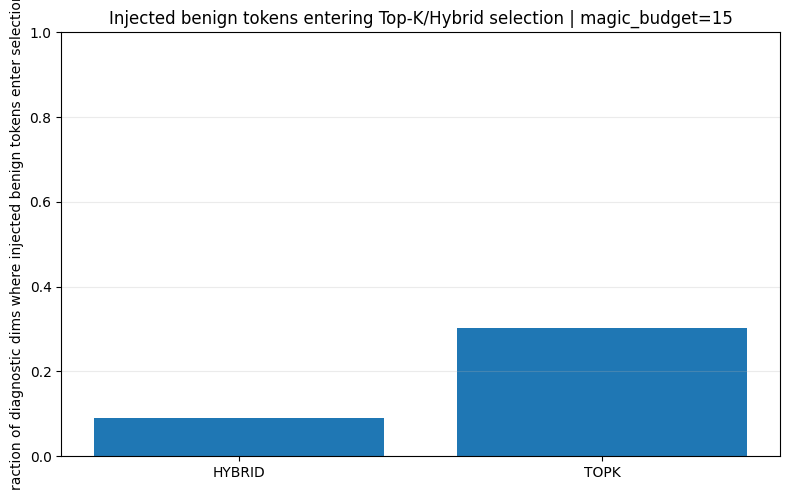

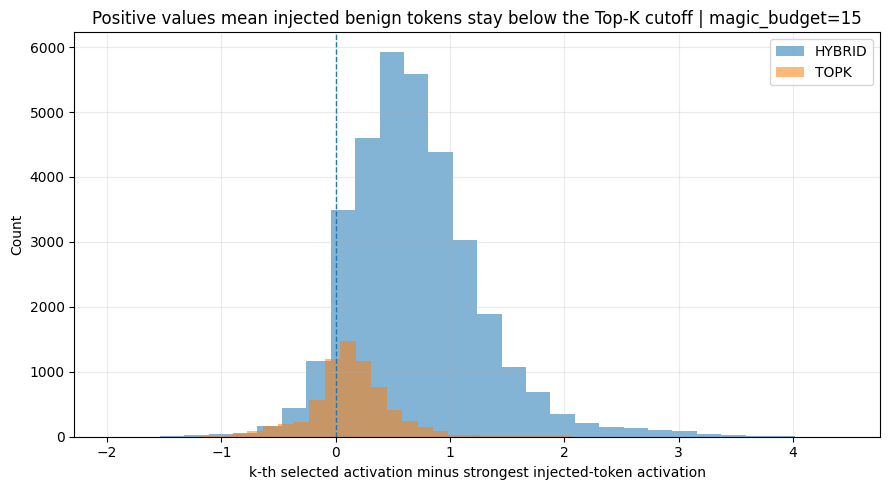


Saved plots:
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/mechanism/plots/frac_dims_injected_enter_selection_magic15.png
 - spam_topk_adv_cv_outputs_concat_enron512_dim_analysis/mechanism/plots/margin_hist_magic15.png


In [ ]:
MECH_ANALYSIS_MAGIC_BUDGET = int(MECH_ANALYSIS_MAGIC_BUDGET)

if "fold_cache" not in globals():
    raise RuntimeError("fold_cache was not found. Run the notebook from the top through Cell 29 first.")

prediction_df = build_prediction_df_from_cache(
    fold_cache=fold_cache,
    model_run_cache=MODEL_RUN_CACHE,
    magic_budget=MECH_ANALYSIS_MAGIC_BUDGET,
)

prediction_csv = os.path.join(MECHANISM_DIR, "prediction_per_sample_for_mechanism.csv")
prediction_df.to_csv(prediction_csv, index=False)
print("Saved:", prediction_csv)

display(prediction_df.head(10))

def _slice_preds(df, model_type, eval_type, k_value=None):
    sub = df[(df["model_type"] == model_type) & (df["eval_type"] == eval_type)].copy()
    if k_value is None:
        return sub
    return sub[sub["k"] == k_value].copy()

mechanism_example_rows = []
mechanism_dimension_rows = []
mechanism_token_rows = []

robust_specs = [("topk", 10), ("hybrid", 3)]
trained_model_cache = {}

for robust_model_type, robust_k in robust_specs:
    print("\n" + "=" * 100)
    print(f"MECHANISM ANALYSIS FOR {robust_model_type.upper()} | K={robust_k}")
    print("=" * 100)

    clean_cls = _slice_preds(prediction_df, "cls", "clean", None)[
        ["fold_id", "sample_pos", "sample_id", "label", "pred_label", "prob_spam"]
    ].rename(columns={"pred_label": "cls_clean_pred", "prob_spam": "cls_clean_prob_spam"})

    adv_cls = _slice_preds(prediction_df, "cls", "adv", None)[
        ["fold_id", "sample_pos", "sample_id", "label", "pred_label", "prob_spam"]
    ].rename(columns={"pred_label": "cls_adv_pred", "prob_spam": "cls_adv_prob_spam"})

    clean_rob = _slice_preds(prediction_df, robust_model_type, "clean", robust_k)[
        ["fold_id", "sample_pos", "sample_id", "label", "pred_label", "prob_spam"]
    ].rename(columns={"pred_label": "robust_clean_pred", "prob_spam": "robust_clean_prob_spam"})

    adv_rob = _slice_preds(prediction_df, robust_model_type, "adv", robust_k)[
        ["fold_id", "sample_pos", "sample_id", "label", "pred_label", "prob_spam"]
    ].rename(columns={"pred_label": "robust_adv_pred", "prob_spam": "robust_adv_prob_spam"})

    merged = clean_cls.merge(
        adv_cls, on=["fold_id", "sample_pos", "sample_id", "label"], how="inner", validate="one_to_one"
    ).merge(
        clean_rob, on=["fold_id", "sample_pos", "sample_id", "label"], how="inner", validate="one_to_one"
    ).merge(
        adv_rob, on=["fold_id", "sample_pos", "sample_id", "label"], how="inner", validate="one_to_one"
    )

    counter_df = merged[
        (merged["label"] == 1) &
        (merged["cls_clean_pred"] == 1) &
        (merged["robust_clean_pred"] == 1) &
        (merged["cls_adv_pred"] == 0) &
        (merged["robust_adv_pred"] == 1)
    ].copy().sort_values(["fold_id", "sample_pos"]).reset_index(drop=True)

    print(f"Counterexamples found for {robust_model_type.upper()} | K={robust_k}: {len(counter_df)}")
    if len(counter_df) == 0:
        continue

    display(counter_df.head(20))

    folds_needed = sorted(counter_df["fold_id"].unique().tolist())
    fold_cache_by_id = {int(fc["fold_id"]): fc for fc in fold_cache}

    for fold_id in folds_needed:
        model_key = (int(fold_id), str(robust_model_type), int(robust_k), int(MECH_ANALYSIS_MAGIC_BUDGET))
        if model_key not in trained_model_cache:
            print(f"Training robust model for fold={fold_id}, model={robust_model_type}, k={robust_k} ...")
            fc = fold_cache_by_id[int(fold_id)]
            trained_model_cache[model_key] = _train_fold_model_for_mechanism(
                fc=fc,
                model_type=robust_model_type,
                k_value=robust_k,
                magic_budget=MECH_ANALYSIS_MAGIC_BUDGET,
            )

        robust_model = trained_model_cache[model_key]
        fc = fold_cache_by_id[int(fold_id)]

        fold_counter_df = counter_df[counter_df["fold_id"] == int(fold_id)].copy()
        for _, row in tqdm(fold_counter_df.iterrows(), total=len(fold_counter_df), desc=f"{robust_model_type}-fold{fold_id}", leave=False):
            ex_row, dim_rows, tok_rows = _analyze_sample_for_robust_model(
                fc=fc,
                sample_pos=int(row["sample_pos"]),
                robust_model=robust_model,
                robust_model_type=robust_model_type,
                robust_k=robust_k,
                cls_prob_spam_adv=float(row["cls_adv_prob_spam"]),
                robust_prob_spam_adv=float(row["robust_adv_prob_spam"]),
            )
            mechanism_example_rows.append(ex_row)
            mechanism_dimension_rows.extend(dim_rows)
            mechanism_token_rows.extend(tok_rows)

mechanism_example_df = pd.DataFrame(mechanism_example_rows)
mechanism_dim_df = pd.DataFrame(mechanism_dimension_rows)
mechanism_token_df = pd.DataFrame(mechanism_token_rows)

mechanism_example_csv = os.path.join(MECHANISM_DIR, "cls_fail_robust_success_examples.csv")
mechanism_dim_csv = os.path.join(MECHANISM_DIR, "cls_fail_robust_success_dimension_rows.csv")
mechanism_token_csv = os.path.join(MECHANISM_DIR, "cls_fail_robust_success_token_rows.csv")

mechanism_example_df.to_csv(mechanism_example_csv, index=False)
mechanism_dim_df.to_csv(mechanism_dim_csv, index=False)
mechanism_token_df.to_csv(mechanism_token_csv, index=False)

print("\nSaved mechanism files:")
print(" -", mechanism_example_csv)
print(" -", mechanism_dim_csv)
print(" -", mechanism_token_csv)

if len(mechanism_example_df) == 0:
    print("No mechanism examples found under the current settings.")
else:
    mechanism_summary_df = (
        mechanism_example_df
        .groupby(["robust_model_type", "robust_k"], dropna=False)
        .agg(
            n_counterexamples=("sample_id", "size"),
            mean_frac_dims_with_injected_selected=("frac_dims_with_injected_selected", "mean"),
            median_frac_dims_with_injected_selected=("frac_dims_with_injected_selected", "median"),
            mean_margin_kth_minus_max_injected_adv=("mean_margin_kth_minus_max_injected_adv", "mean"),
            median_margin_kth_minus_max_injected_adv=("median_margin_kth_minus_max_injected_adv", "median"),
            mean_cls_adv_prob_spam=("cls_adv_prob_spam", "mean"),
            mean_robust_adv_prob_spam=("robust_adv_prob_spam", "mean"),
        )
        .reset_index()
        .sort_values(["robust_model_type", "robust_k"])
        .reset_index(drop=True)
    )

    mechanism_dim_summary_df = (
        mechanism_dim_df
        .groupby(["robust_model_type", "robust_k"], dropna=False)
        .agg(
            n_dim_rows=("representation_dim", "size"),
            frac_dims_injected_enter_topk=("injected_enters_topk_set_adv", "mean"),
            mean_num_injected_selected_adv=("num_injected_tokens_selected_adv", "mean"),
            median_num_injected_selected_adv=("num_injected_tokens_selected_adv", "median"),
            mean_margin_kth_minus_max_injected_adv=("margin_kth_minus_max_injected_adv", "mean"),
            median_margin_kth_minus_max_injected_adv=("margin_kth_minus_max_injected_adv", "median"),
            mean_clean_spam_contribution=("clean_spam_contribution", "mean"),
            mean_adv_spam_contribution=("adv_spam_contribution", "mean"),
        )
        .reset_index()
        .sort_values(["robust_model_type", "robust_k"])
        .reset_index(drop=True)
    )

    mechanism_summary_csv = os.path.join(MECHANISM_DIR, "cls_fail_robust_success_example_summary.csv")
    mechanism_dim_summary_csv = os.path.join(MECHANISM_DIR, "cls_fail_robust_success_dimension_summary.csv")
    mechanism_summary_df.to_csv(mechanism_summary_csv, index=False)
    mechanism_dim_summary_df.to_csv(mechanism_dim_summary_csv, index=False)

    print("\nSaved summary files:")
    print(" -", mechanism_summary_csv)
    print(" -", mechanism_dim_summary_csv)

    print("\nExample-level summary:")
    display(mechanism_summary_df)

    print("\nDimension-level summary:")
    display(mechanism_dim_summary_df)

    print("\nTop counterexamples:")
    cols = [
        "robust_model_type", "robust_k", "fold_id", "sample_pos", "sample_id",
        "cls_adv_prob_spam", "robust_adv_prob_spam",
        "frac_dims_with_injected_selected", "mean_margin_kth_minus_max_injected_adv",
        "magic_words_str", "clean_text_preview", "adv_text_preview"
    ]
    display(
        mechanism_example_df.sort_values(
            ["robust_model_type", "frac_dims_with_injected_selected", "mean_margin_kth_minus_max_injected_adv", "fold_id", "sample_pos"],
            ascending=[True, True, False, True, True]
        )[cols].head(20)
    )

    plt.figure(figsize=(8, 5))
    bars = mechanism_dim_summary_df["robust_model_type"].str.upper()
    plt.bar(bars, mechanism_dim_summary_df["frac_dims_injected_enter_topk"])
    plt.ylim(0, 1)
    plt.ylabel("Fraction of diagnostic dims where injected benign tokens enter selection")
    plt.title(f"Injected benign tokens entering Top-K/Hybrid selection | magic_budget={MECH_ANALYSIS_MAGIC_BUDGET}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plot1 = os.path.join(MECHANISM_PLOT_DIR, f"frac_dims_injected_enter_selection_magic{MECH_ANALYSIS_MAGIC_BUDGET}.png")
    plt.savefig(plot1, dpi=200, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    for model_name in sorted(mechanism_dim_df["robust_model_type"].unique()):
        vals = mechanism_dim_df.loc[
            mechanism_dim_df["robust_model_type"] == model_name,
            "margin_kth_minus_max_injected_adv"
        ].dropna().to_numpy()
        if len(vals) == 0:
            continue
        plt.hist(vals, bins=30, alpha=0.55, label=model_name.upper())
    plt.axvline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("k-th selected activation minus strongest injected-token activation")
    plt.ylabel("Count")
    plt.title(f"Positive values mean injected benign tokens stay below the Top-K cutoff | magic_budget={MECH_ANALYSIS_MAGIC_BUDGET}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plot2 = os.path.join(MECHANISM_PLOT_DIR, f"margin_hist_magic{MECH_ANALYSIS_MAGIC_BUDGET}.png")
    plt.savefig(plot2, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved plots:")
    print(" -", plot1)
    print(" -", plot2)

In [ ]:

INSPECT_ROBUST_MODEL = "topk"   
INSPECT_SAMPLE_RANK = 0      
INSPECT_DIAG_DIMS_TO_SHOW = 6

if "mechanism_example_df" not in globals() or len(mechanism_example_df) == 0:
    print("No mechanism examples found. Run the previous mechanism cell first.")
else:
    sub_examples = mechanism_example_df[
        mechanism_example_df["robust_model_type"] == INSPECT_ROBUST_MODEL
    ].copy()

    if len(sub_examples) == 0:
        print(f"No rows available for robust model = {INSPECT_ROBUST_MODEL}")
    else:
        sub_examples = sub_examples.sort_values(
            ["frac_dims_with_injected_selected", "mean_margin_kth_minus_max_injected_adv", "fold_id", "sample_pos"],
            ascending=[True, False, True, True]
        ).reset_index(drop=True)

        picked = sub_examples.iloc[int(INSPECT_SAMPLE_RANK)]
        print("Picked counterexample:")
        display(picked.to_frame().T)

        sub_dims = mechanism_dim_df[
            (mechanism_dim_df["robust_model_type"] == str(picked["robust_model_type"])) &
            (mechanism_dim_df["fold_id"] == int(picked["fold_id"])) &
            (mechanism_dim_df["sample_pos"] == int(picked["sample_pos"]))
        ].copy().sort_values("diagnostic_rank").head(int(INSPECT_DIAG_DIMS_TO_SHOW))

        display_cols = [
            "diagnostic_rank", "representation_dim", "base_hidden_dim",
            "spam_weight_delta", "clean_pooled_value", "adv_pooled_value",
            "clean_spam_contribution", "adv_spam_contribution",
            "num_injected_tokens_selected_adv", "injected_enters_topk_set_adv",
            "max_injected_activation_adv", "kth_selected_activation_adv",
            "margin_kth_minus_max_injected_adv",
            "adv_selected_tokens_compact"
        ]
        print("\nDiagnostic dimensions:")
        display(sub_dims[display_cols])

        sub_tokens = mechanism_token_df[
            (mechanism_token_df["robust_model_type"] == str(picked["robust_model_type"])) &
            (mechanism_token_df["fold_id"] == int(picked["fold_id"])) &
            (mechanism_token_df["sample_pos"] == int(picked["sample_pos"])) &
            (mechanism_token_df["diagnostic_rank"].isin(sub_dims["diagnostic_rank"].tolist()))
        ].copy().sort_values(["diagnostic_rank", "eval_view", "token_group", "token_rank"])

        print("\nToken-level rows (selected tokens + injected suffix tokens):")
        display(sub_tokens.head(300))

Picked counterexample:


,magic_word_budget,fold_id,sample_pos,sample_id,label,robust_model_type,robust_k,n_diag_dims,frac_dims_with_injected_selected,mean_margin_kth_minus_max_injected_adv,median_margin_kth_minus_max_injected_adv,cls_adv_prob_spam,robust_adv_prob_spam,magic_words_str,clean_text_preview,adv_text_preview
0,15,4,2192,fold4_pos2192,1,topk,10,12,0.0,1.636356,1.758021,0.193397,0.612293,listbot kaminski enrononline ena ferc hemmings...,Subject: validation your ebay account could be...,Subject: validation your ebay account could be...



Diagnostic dimensions:


,diagnostic_rank,representation_dim,base_hidden_dim,spam_weight_delta,clean_pooled_value,adv_pooled_value,clean_spam_contribution,adv_spam_contribution,num_injected_tokens_selected_adv,injected_enters_topk_set_adv,max_injected_activation_adv,kth_selected_activation_adv,margin_kth_minus_max_injected_adv,adv_selected_tokens_compact
6876,1,55,55,0.069779,2.015932,2.010712,0.140670,0.140305,0,0,0.124609,1.918422,1.793813,82:initiated|2.1618 ; 90:made|2.1481 ; 31:more...
6877,2,683,683,0.064979,1.973925,2.176251,0.128264,0.141411,0,0,-0.122873,2.131557,2.254431,89:was|2.2112 ; 29:one|2.2079 ; 53:your|2.1956...
6878,3,734,734,0.061462,1.956464,2.138795,0.120248,0.131454,0,0,0.345896,2.091125,1.745229,101:.|2.1816 ; 202:will|2.1814 ; 172:an|2.1811...
6879,4,266,266,0.053448,2.205287,1.990647,0.117868,0.106396,0,0,-0.473971,1.937602,2.411573,268:search|2.1551 ; 40:account|2.0269 ; 7:acco...
6880,5,461,461,0.056862,1.903683,0.967653,0.108247,0.055022,0,0,-0.936282,0.928361,1.864643,18:must|1.0330 ; 250:will|1.0319 ; 368:.|0.993...
6881,6,253,253,0.060137,1.778288,1.054665,0.106941,0.063425,0,0,-0.670565,0.987996,1.658561,249:reply|1.2274 ; 84:you|1.1017 ; 8:could|1.0...



Token-level rows (selected tokens + injected suffix tokens):


,magic_word_budget,fold_id,sample_pos,sample_id,robust_model_type,robust_k,diagnostic_rank,representation_dim,base_hidden_dim,eval_view,token_group,token_rank,token_pos,token,activation,is_injected_token
286652,15,4,2192,fold4_pos2192,topk,10,1,55,55,adv,injected,1,401,list,-0.245029,1
286653,15,4,2192,fold4_pos2192,topk,10,1,55,55,adv,injected,2,402,##bot,-0.155254,1
286654,15,4,2192,fold4_pos2192,topk,10,1,55,55,adv,injected,3,403,kam,-0.293515,1
286655,15,4,2192,fold4_pos2192,topk,10,1,55,55,adv,injected,4,404,##inski,-0.006659,1
286656,15,4,2192,fold4_pos2192,topk,10,1,55,55,adv,injected,5,405,en,-0.212882,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286832,15,4,2192,fold4_pos2192,topk,10,6,253,253,clean,selected,6,270,##bay,1.764049,0
286833,15,4,2192,fold4_pos2192,topk,10,6,253,253,clean,selected,7,398,##bay,1.761562,0
286834,15,4,2192,fold4_pos2192,topk,10,6,253,253,clean,selected,8,249,reply,1.758849,0
286835,15,4,2192,fold4_pos2192,topk,10,6,253,253,clean,selected,9,263,##bay,1.756268,0
